In [2]:
from pathlib import Path

# =====================================
# CONFIG — Aligned to Final COVID-19/BUSI Pipeline
# =====================================
CONFIG = {
    # Paths - Fixed structure (Kaggle)
    'data_root': '/kaggle/input/datasets/yasserhessein/the-kvasir-dataset/kvasir-dataset-v2',
    'image_dir': '/kaggle/input/datasets/yasserhessein/the-kvasir-dataset/kvasir-dataset-v2',

    # Output Directories — must be consistent across datasets
    'output_dir': '/kaggle/working/outputs',
    'checkpoint_dir': '/kaggle/working/checkpoints',
    'results_dir': '/kaggle/working/results',
    'figures_dir': '/kaggle/working/figures',

    # Kvasir v2 Classes — 8 gastrointestinal categories (all subfolders)
    'class_names': [
        'dyed-lifted-polyps',
        'dyed-resection-margins',
        'esophagitis',
        'normal-cecum',
        'normal-pylorus',
        'normal-z-line',
        'polyps',
        'ulcerative-colitis',
    ],
    'num_classes': 8,

    # Split Configuration
    'val_size': 0.10,   # Use val_size only → split train/val/test as (80/10/10)
    # No test_size — derived in code

    # Training Hyperparameters — aligned with final COVID/BUSI standard
    'image_size': 224,
    'batch_size': 32,
    'num_epochs': 20,              # ← UPDATED: from 8 → 20
    'retrain_epochs': 10,           # ← UPDATED: from 3 → 10
    'lr': 1e-4,
    'retrain_lr': 5e-5,
    'weight_decay': 1e-4,
    'seed': 42,
    'num_workers': 4,
    'patience': 5,                  # ← UPDATED: from 3 → 5
    'retrain_patience': 5,          # ← UPDATED: from 2 → 3
    'max_samples': None,
    'show_batch_progress': False,
    'prefetch_factor': 2,

    # Failure Analysis - Aligned
    'pca_components': 32,
    'umap_neighbors': 15,
    'umap_min_dist': 0.1,
    'k_range': range(2, 7),
    'small_failure_umap_threshold': 300,
    'max_aug_source': 300,
    'ece_bins': 15,
    'aug_multiplier': 3,

    # Degradation Guard - Aligned
    'guard_f1_max_drop'       : 0.000,
    'guard_acc_max_drop'      : 0.005,
    'guard_ece_max_rise'      : 0.010,
    'guard_weak_baseline_f1'  : 0.55,
    'guard_weak_f1_max_drop'  : 0.005,
    'guard_weak_acc_max_drop' : 0.010,
    'guard_weak_ece_max_rise' : 0.025,
}

MODELS = [
    'resnet50',
    'resnet101',
    # # 'densenet121',
    # # 'efficientnet_b3',
    # # 'efficientnet_b5',
    # # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvit_tiny_tf_224',
]

# Ensure output directories exist when notebook starts
for d in [CONFIG['output_dir'], CONFIG['checkpoint_dir'], CONFIG['results_dir'], CONFIG['figures_dir']]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("? CONFIG loaded - Kvasir v2 | 8-class | val split from training")
print(f"  Classes    : {CONFIG['class_names']}")
print(f"  Training   : {CONFIG['num_epochs']} epochs | lr={CONFIG['lr']} | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs | lr={CONFIG['retrain_lr']} | patience={CONFIG['retrain_patience']}")


? CONFIG loaded - Kvasir v2 | 8-class | val split from training
  Classes    : ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
  Training   : 20 epochs | lr=0.0001 | patience=5
  Retraining : 10 epochs | lr=5e-05 | patience=5


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 72.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

2026-06-16 21:40:39.583825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781646039.795241      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781646039.863460      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781646040.350789      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781646040.350835      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781646040.350838      22 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


In [4]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")


Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using Kvasir v2 root: /kaggle/input/datasets/yasserhessein/the-kvasir-dataset/kvasir-dataset-v2

Total Kvasir v2 images loaded: 8,000

Class distribution:
label_name
dyed-lifted-polyps        1000
dyed-resection-margins    1000
esophagitis               1000
normal-cecum              1000
normal-pylorus            1000
normal-z-line             1000
polyps                    1000
ulcerative-colitis        1000
Name: count, dtype: int64
Splits -> Train: 6,400 | Val: 800 | Test: 800

Train distribution:
label_name
dyed-lifted-polyps        800
dyed-resection-margins    800
esophagitis               800
normal-cecum              800
normal-pylorus            800
normal-z-line             800
polyps                    800
ulcerative-colitis        800
Name: count, dtype: int64

Val distribution:
label_name
dyed-lifted-polyps        100
dyed-resection-margins    100
esophagitis               100
normal-cecum              100
normal-pylorus            100
normal-z-line             100
polyps

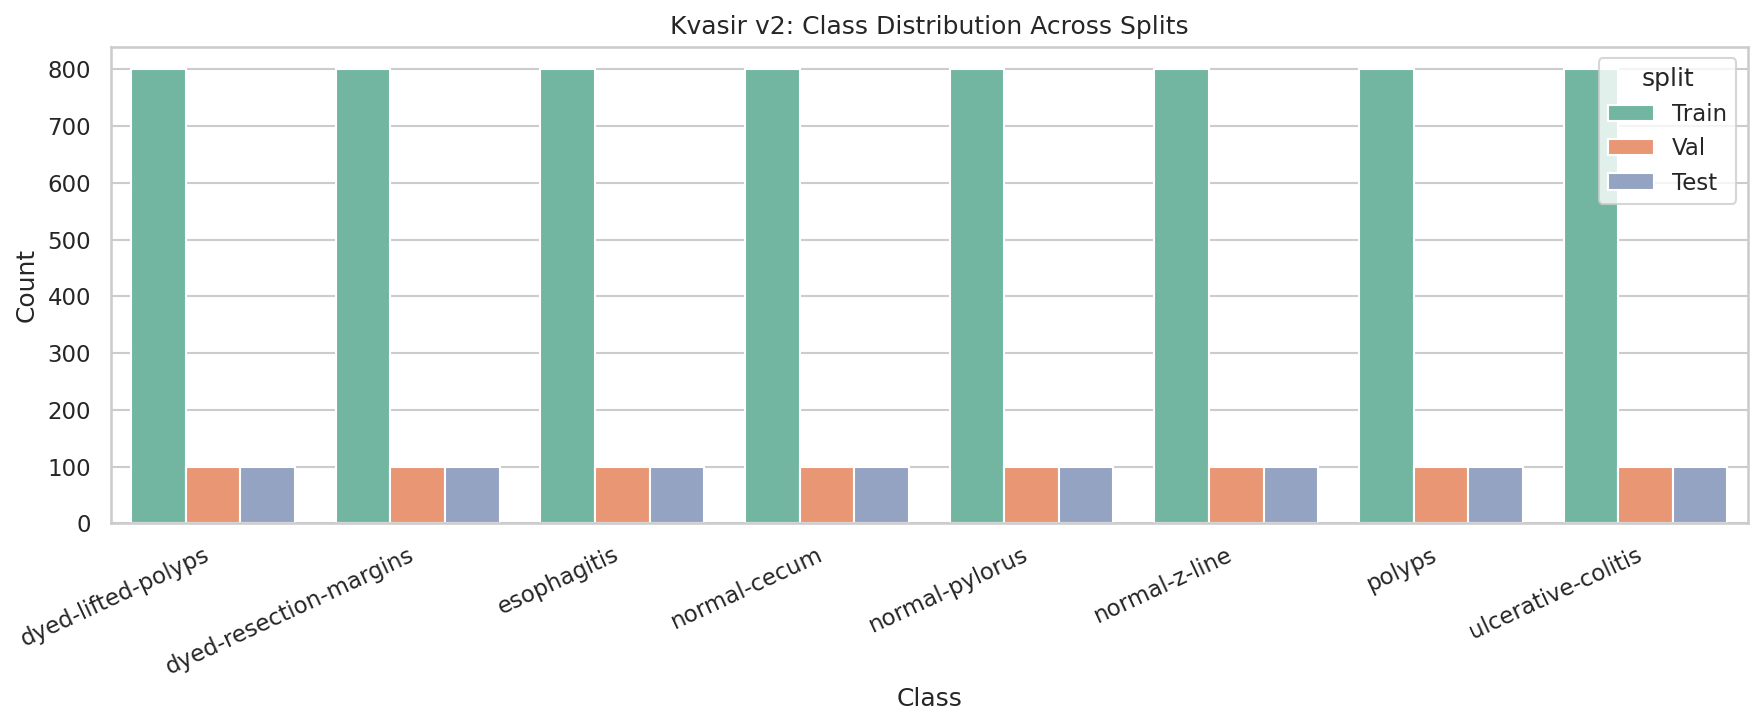

? Section 2 complete


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# =====================================
# Section 2: Data Loading & Stratified Split
# =====================================

def list_kvasir_images(root: Path, class_name: str) -> pd.DataFrame:
    """
    List image files for one Kvasir v2 class.
    Returns image stem, path, and label.
    """
    class_dir = root / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Missing class folder for {class_name}: {class_dir}")

    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    paths = sorted(
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in exts
    )
    if len(paths) == 0:
        raise FileNotFoundError(f"No image files found in: {class_dir}")

    return pd.DataFrame({
        'image': [p.stem for p in paths],
        'image_path': [str(p) for p in paths],
        'label_name': class_name,
        'original_labels': class_name,
    })


def preprocess_labels(config: dict):
    """
    Build stratified train/val/test splits for Kvasir v2.
    - Splits the full dataset using val_size only
    - Saves CSVs and class distribution plot
    """
    image_dir = Path(config['image_dir'])

    if not image_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {image_dir}")

    # Ensure output directories exist
    Path(config['figures_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['results_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    print(f"Using Kvasir v2 root: {image_dir}")

    # Load all class folders
    full_df = pd.concat(
        [list_kvasir_images(image_dir, class_name) for class_name in config['class_names']],
        ignore_index=True
    )

    # Map class names to indices
    label_to_idx = {name: idx for idx, name in enumerate(config['class_names'])}
    full_df['label'] = full_df['label_name'].map(label_to_idx).astype(int)
    full_df = full_df[['image', 'image_path', 'label', 'label_name', 'original_labels']].reset_index(drop=True)

    # Verify data
    print(f"\nTotal Kvasir v2 images loaded: {len(full_df):,}")
    print("\nClass distribution:")
    print(full_df['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Split: Train + Val + Test = 80/10/10
    val_size_total = config.get('val_size', 0.2)  # Usually 0.10 → 10% val + 10% test
    test_size = 0.2  # First: split off 20% (Val+Test)
    val_fraction_in_train_val = val_size_total / test_size if test_size > 0 else 0.5  # Scale val proportion

    # First split: Train / (Val+Test)
    train_val_df, temp_df = train_test_split(
        full_df,
        test_size=test_size,
        random_state=config['seed'],
        stratify=full_df['label']
    )

    # Second split: Val / Test from 20%
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,  # Split Val/Test evenly
        random_state=config['seed'],
        stratify=temp_df['label']
    )

    # Reset indices
    train_df = train_val_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    print(f"Splits -> Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

    # Print split distributions
    for split_name, split_data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"\n{split_name} distribution:")
        print(split_data['label_name'].value_counts().reindex(config['class_names']).fillna(0).astype(int))

    # Save CSVs
    splits = {
        'train_split.csv': train_df,
        'val_split.csv': val_df,
        'test_split.csv': test_df
    }
    for fname, df_split in splits.items():
        # Save to Kaggle root for preview
        df_split.to_csv(f"/kaggle/working/{fname}", index=False)
        # And to results_dir for consistency
        df_split.to_csv(f"{config['results_dir']}/{fname}", index=False)

    print("\nTrain/val/test splits saved to /kaggle/working/ and results_dir")

    # Plot: Class distribution per split
    dist = pd.concat([
        train_df.assign(split='Train'),
        val_df.assign(split='Val'),
        test_df.assign(split='Test'),
    ])

    plt.figure(figsize=(12, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    plt.xticks(rotation=25, ha='right')
    plt.title("Kvasir v2: Class Distribution Across Splits", fontsize=12)
    plt.tight_layout()

    # Save high-res plot
    plot_path = f"{config['figures_dir']}/section2_class_distribution.png"
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    return train_df, val_df, test_df


# =============================
# Run preprocessing
# =============================
train_df, val_df, test_df = preprocess_labels(CONFIG)
print("? Section 2 complete")

In [6]:
# =====================================
# Section 3: Dataset Definition & DataLoaders
# Aligned to unified pipeline (shared with BUSI, COVID)
# =====================================
# import torch
# import numpy as np
# from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# from torchvision import transforms as T
# from torchvision.transforms import functional as F
# from PIL import Image
# import pandas as pd

# =====================================
# Dataset Class — Kvasir v2
# =====================================
class KvasirDataset(Dataset):
    """Kvasir v2 endoscopy dataset: load RGB inputs for transfer learning."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            KvasirDataset.missing_warning_count += 1
            if KvasirDataset.missing_warning_count <= 10:
                print(f"Warning: missing image, using blank: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            KvasirDataset.missing_warning_count += 1
            if KvasirDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


# =====================================
# Transforms (Shared across datasets)
# =====================================
def get_transforms(split: str, image_size: int):
    """Standardized transforms using ImageNet mean/std."""
    mean = [0.485, 0.456, 0.406]  # ImageNet
    std  = [0.229, 0.224, 0.225]

    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    elif split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.2),
            T.RandomRotation(degrees=25),
            T.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.25, hue=0.05),
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:  # 'val', 'test'
        return T.Compose([
            T.Resize(image_size),
            T.CenterCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])


# =====================================
# Augmented Dataset (for retraining failure clusters)
# =====================================
class AugmentedKvasirDataset(KvasirDataset):
    """Applies heavy augmentation if row['is_augmented'] = True."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


# =====================================
# Class Weights & Dataloader Factory
# =====================================
def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute class-balanced weights for loss."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)  # Inverse frequency
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: dict,
    val_df: pd.DataFrame = None
):
    """Build consistent DataLoaders with WeightedRandomSampler."""
    # Use provided val_df, or split from train_df
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df,
            test_size=config.get('val_size', 0.1),
            random_state=config['seed'],
            stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    # Transforms
    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    # Datasets
    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedKvasirDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = KvasirDataset(train_split, train_transform, config['image_dir'])
    
    val_ds = KvasirDataset(val_split, eval_transform, config['image_dir'])
    test_ds = KvasirDataset(test_df, eval_transform, config['image_dir'])

    # Class and sample weights
    class_weights = compute_class_weights(train_split, config['num_classes'])
    
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        label_weight_map = {i: class_weights[i].item() for i in range(config['num_classes'])}
        sample_weights = train_split['label'].map(label_weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

    # DataLoader kwargs
    loader_kwargs = {
        'batch_size': config['batch_size'],
        'num_workers': config['num_workers'],
        'pin_memory': True,
        'persistent_workers': True if config['num_workers'] > 0 else False,
    }
    if config['num_workers'] > 0:
        loader_kwargs['prefetch_factor'] = config.get('prefetch_factor', 2)

    # Loaders
    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader, class_weights


# =============================
# Run Dataloader Creation
# =============================
train_loader, val_loader, test_loader, class_weights = get_dataloaders(
    train_df, test_df, CONFIG, val_df=val_df
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("? Section 3 complete")

Train batches: 200 | Val batches: 25 | Test batches: 25
Class weights: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
? Section 3 complete


In [7]:
# =====================================
# Section 4: Model Definition & Embedding Hook
# Fully aligned with final pipeline (Covid, BUSI)
# =====================================
import torch
import torch.nn as nn
import torchvision.models as models
import timm


# =====================================
# get_model — Unified model loader
# =====================================
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Load torchvision or timm model with customizable head.
    Returns model moved to device (CPU/GPU).
    """
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )
    
    model = model.to(device)
    
    # Model summary
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    
    return model


# =====================================
# get_embedding_hook — Penultimate layer hook
# =====================================
def get_embedding_hook(model: nn.Module, model_name: str):
    """
    Registers a forward hook to extract the penultimate-layer representation.
    Supports CNNs and Transformers.
    Returns: handle, embedding_store (for later retrieval).
    """
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        if isinstance(out, (tuple, list)):
            out = out[0]  # Handle multiple outputs (e.g., ViT)

        if out.ndim == 4:  # CNN: (B, C, H, W)
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        elif out.ndim == 3:  # Transformer: (B, N, D)
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        else:  # Flatten if 1D
            out = out.flatten(1)

        embedding_store['embedding'] = out.detach().cpu()

    # Determine penultimate layer based on architecture
    target = None

    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        # ConvNeXt: use stem-norm or head global_pool
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    if target is None:
        if hasattr(model, 'forward_features'):
            raise ValueError(
                f"No known penultimate layer for model '{model_name}'. "
                "Please define the embedding layer explicitly.")
        else:
            raise ValueError(
                f"Model '{model_name}' not supported. No known feature extractor.")

    # Register hook
    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


# =====================================
# get_model_family — Group models for retraining strategy
# =====================================
def get_model_family(model_name: str) -> str:
    """
    Group models to apply family-specific retraining strategies (strategy in Section 10).
    """
    if model_name.startswith('efficientnet'):
        return 'efficient'
    if model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    return 'cnn'


print("✓ Section 4 complete")

✓ Section 4 complete


In [8]:
# =====================================
# Section 5: Training & Evaluation
# Fully aligned with final pipeline (Covid-19 / BUSI)
# =====================================
from torch.cuda.amp import autocast, GradScaler
from torchmetrics import classification as torchmetrics_classification
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
from pathlib import Path

# =====================================
# train_one_epoch: Mixed Precision
# =====================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """
    Train one epoch using CUDA mixed precision.
    Returns average loss and accuracy.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in tqdm(
        loader,
        desc='train',
        leave=False,
        disable=not CONFIG.get('show_batch_progress', False)
    ):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(total, 1), correct / max(total, 1)


# =====================================
# evaluate: Full Metrics + Outputs
# =====================================
def evaluate(model, loader, criterion, device, num_classes, class_names):
    """
    Evaluate model on loader.
    Returns:
      loss, acc, F1, AUC, ECE,
      probs, labels, preds, paths
    """
    model.eval()
    f1_metric = torchmetrics_classification.F1Score(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)

    auc_metric = torchmetrics_classification.AUROC(
        task='multiclass',
        num_classes=num_classes,
        average='macro'
    ).to(device)

    total_loss = correct = total = 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []

    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc='eval',
            leave=False,
            disable=not CONFIG.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)

            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)

            probs_all.append(probs.cpu().numpy())
            labels_all.append(labels.cpu().numpy())
            preds_all.append(preds.cpu().numpy())
            paths_all.extend(list(paths))

    # Concatenate arrays
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])

    try:
        auc = float(auc_metric.compute().cpu())
    except Exception as e:
        print(f"⚠️ AUROC computation failed: {e}")
        auc = np.nan

    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan

    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


# =====================================
# compute_ece: Expected Calibration Error
# =====================================
def compute_ece(probs_array, labels_array, n_bins=15):
    """
    Compute Expected Calibration Error (ECE).
    Bins confidence of predictions and computes gap between mean confidence and accuracy.
    """
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)

    if len(labels_array) == 0:
        return np.nan

    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


# =====================================
# plot_confusion_matrix: Normalized Plot
# =====================================
def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """
    Plot normalized confusion matrix.
    Save with dataset-identifying name.
    """
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=(row_sums != 0)
    )
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({suffix.title()})")
    plt.tight_layout()
    if save:
        save_path = f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✅ Confusion matrix saved: {save_path}")
    plt.show()


# =====================================
# train_model: Full Training Loop
# =====================================
def train_model(model_name, train_loader, val_loader, class_weights, config):
    """
    Train baseline model with early stopping on val macro F1.
    Returns:
      - model: final loaded best model
      - history: dict of loss/acc curves
      - best_val_metrics: dict with 'val_acc', 'val_f1', etc. (safe keys)
    """
    print(f"\n{'='*60}")
    print(f" TRAINING: {model_name} (Kvasir v2)")
    print(f"{'='*60}")

    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0

    # Default fallback
    best_val_metrics = {
        'val_loss': float('nan'),
        'val_acc': float('nan'),
        'val_f1': float('nan'),
        'val_auc': float('nan'),
        'val_ece': float('nan'),
    }

    ckpt_path = Path(config['checkpoint_dir']) / f"best_kvasir_{model_name}.pth"
    Path(config['checkpoint_dir']).mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} | {model_name}")

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])

        print(f"  TRAIN loss: {train_loss:.4f} | acc: {train_acc:.3f}")
        print(f"  VAL   loss: {val_metrics['loss']:.4f} | acc: {val_metrics['accuracy']:.3f} | F1: {val_metrics['f1']:.4f} | ECE: {val_metrics['ece']:.4f}")

        # Save best model by F1
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            best_val_metrics = {
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
                'val_ece': val_metrics['ece'],
            }
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  ✅ Saved best model (F1={best_f1:.4f}): {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  ⚠️ Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    # Load best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    print(f"✅ Training complete: best weights loaded from {ckpt_path}")

    return model, dict(history), best_val_metrics


print("✓ Section 5 complete")

✓ Section 5 complete



✓ Starting evaluation for 2 models — Kvasir v2


Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]


  TRAINING: resnet50

 TRAINING: resnet50 (Kvasir v2)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
 23%|██▎       | 22.4M/97.8M [00:00<00:00, 234MB/s]
 46%|████▌     | 44.8M/97.8M [00:00<00:00, 230MB/s]
 69%|██████▉   | 67.4M/97.8M [00:00<00:00, 233MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 230MB/s]


resnet50: 23.52M params (23.52M trainable)
Epoch 1/20 | resnet50
  TRAIN loss: 0.6428 | acc: 0.798
  VAL   loss: 0.2613 | acc: 0.897 | F1: 0.8972 | ECE: 0.0194
  ✅ Saved best model (F1=0.8972): /kaggle/working/checkpoints/best_kvasir_resnet50.pth
Epoch 2/20 | resnet50
  TRAIN loss: 0.2495 | acc: 0.910
  VAL   loss: 0.2756 | acc: 0.894 | F1: 0.8935 | ECE: 0.0318
Epoch 3/20 | resnet50
  TRAIN loss: 0.1947 | acc: 0.925
  VAL   loss: 0.3073 | acc: 0.891 | F1: 0.8902 | ECE: 0.0476
Epoch 4/20 | resnet50
  TRAIN loss: 0.1658 | acc: 0.943
  VAL   loss: 0.2666 | acc: 0.910 | F1: 0.9093 | ECE: 0.0320
  ✅ Saved best model (F1=0.9093): /kaggle/working/checkpoints/best_kvasir_resnet50.pth
Epoch 5/20 | resnet50
  TRAIN loss: 0.1242 | acc: 0.955
  VAL   loss: 0.2410 | acc: 0.924 | F1: 0.9237 | ECE: 0.0418
  ✅ Saved best model (F1=0.9237): /kaggle/working/checkpoints/best_kvasir_resnet50.pth
Epoch 6/20 | resnet50
  TRAIN loss: 0.1049 | acc: 0.963
  VAL   loss: 0.2321 | acc: 0.919 | F1: 0.9186 | ECE: 0

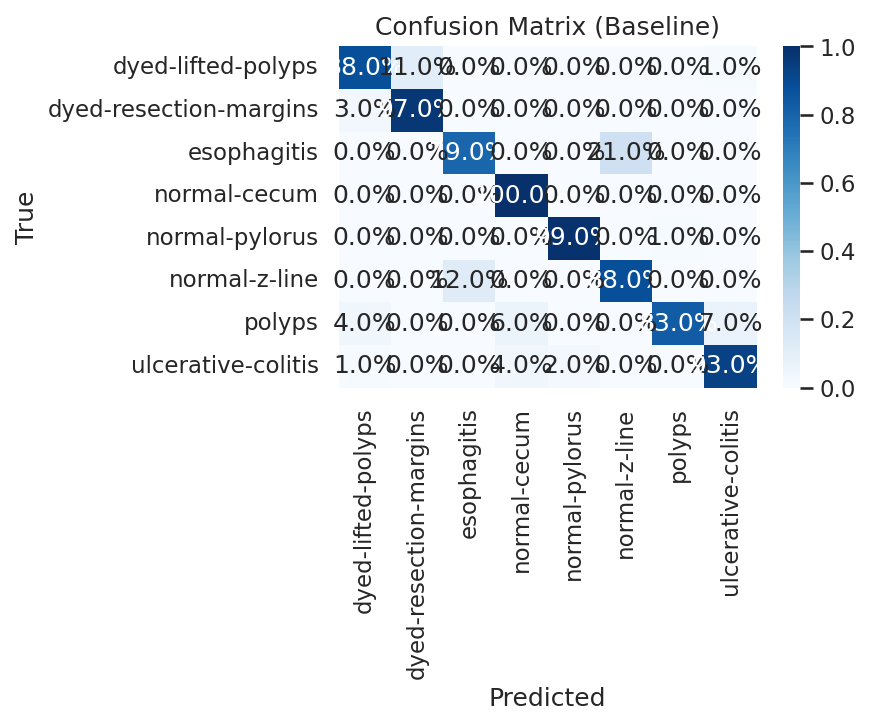

Evaluating models:  50%|█████     | 1/2 [38:57<38:57, 2337.23s/it]


  TRAINING: resnet101

 TRAINING: resnet101 (Kvasir v2)
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth



  0%|          | 0.00/171M [00:00<?, ?B/s]
 10%|▉         | 16.5M/171M [00:00<00:00, 173MB/s]
 22%|██▏       | 36.8M/171M [00:00<00:00, 195MB/s]
 33%|███▎      | 56.9M/171M [00:00<00:00, 202MB/s]
 46%|████▌     | 78.4M/171M [00:00<00:00, 211MB/s]
 59%|█████▉    | 101M/171M [00:00<00:00, 220MB/s] 
 72%|███████▏  | 123M/171M [00:00<00:00, 224MB/s]
 85%|████████▌ | 146M/171M [00:00<00:00, 228MB/s]
100%|██████████| 171M/171M [00:00<00:00, 215MB/s]


resnet101: 42.52M params (42.52M trainable)
Epoch 1/20 | resnet101
  TRAIN loss: 0.5979 | acc: 0.809
  VAL   loss: 0.2584 | acc: 0.899 | F1: 0.8982 | ECE: 0.0309
  ✅ Saved best model (F1=0.8982): /kaggle/working/checkpoints/best_kvasir_resnet101.pth
Epoch 2/20 | resnet101
  TRAIN loss: 0.2217 | acc: 0.919
  VAL   loss: 0.2398 | acc: 0.905 | F1: 0.9042 | ECE: 0.0344
  ✅ Saved best model (F1=0.9042): /kaggle/working/checkpoints/best_kvasir_resnet101.pth
Epoch 3/20 | resnet101
  TRAIN loss: 0.1557 | acc: 0.945
  VAL   loss: 0.2274 | acc: 0.912 | F1: 0.9124 | ECE: 0.0275
  ✅ Saved best model (F1=0.9124): /kaggle/working/checkpoints/best_kvasir_resnet101.pth
Epoch 4/20 | resnet101
  TRAIN loss: 0.1203 | acc: 0.959
  VAL   loss: 0.2859 | acc: 0.910 | F1: 0.9100 | ECE: 0.0464
Epoch 5/20 | resnet101
  TRAIN loss: 0.0970 | acc: 0.964
  VAL   loss: 0.2035 | acc: 0.922 | F1: 0.9225 | ECE: 0.0393
  ✅ Saved best model (F1=0.9225): /kaggle/working/checkpoints/best_kvasir_resnet101.pth
Epoch 6/20 | r

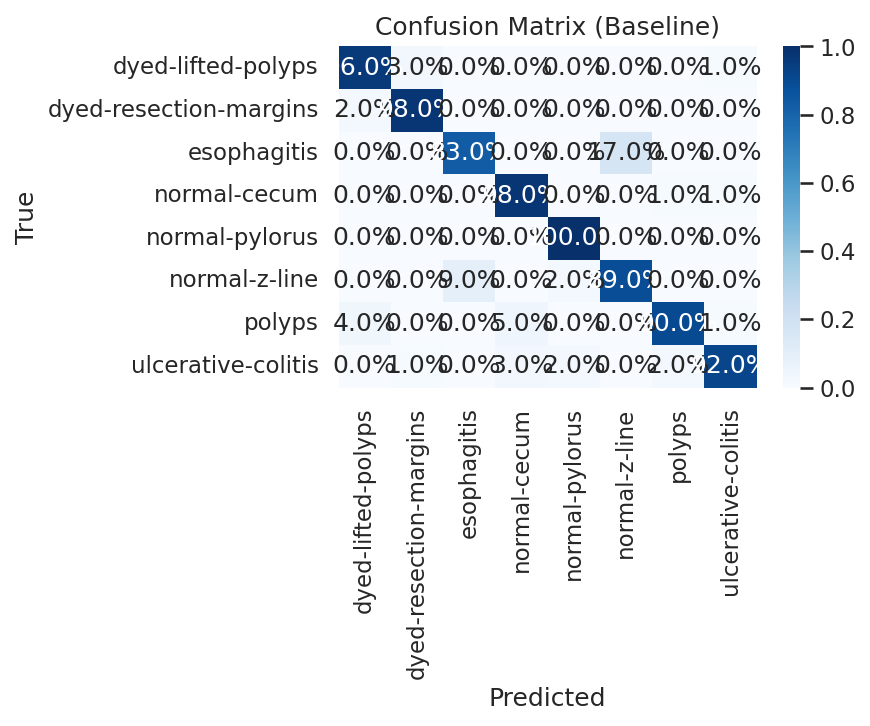

Evaluating models: 100%|██████████| 2/2 [1:57:22<00:00, 3521.09s/it]



✅ Baseline results saved: /kaggle/working/results/baseline_results.csv


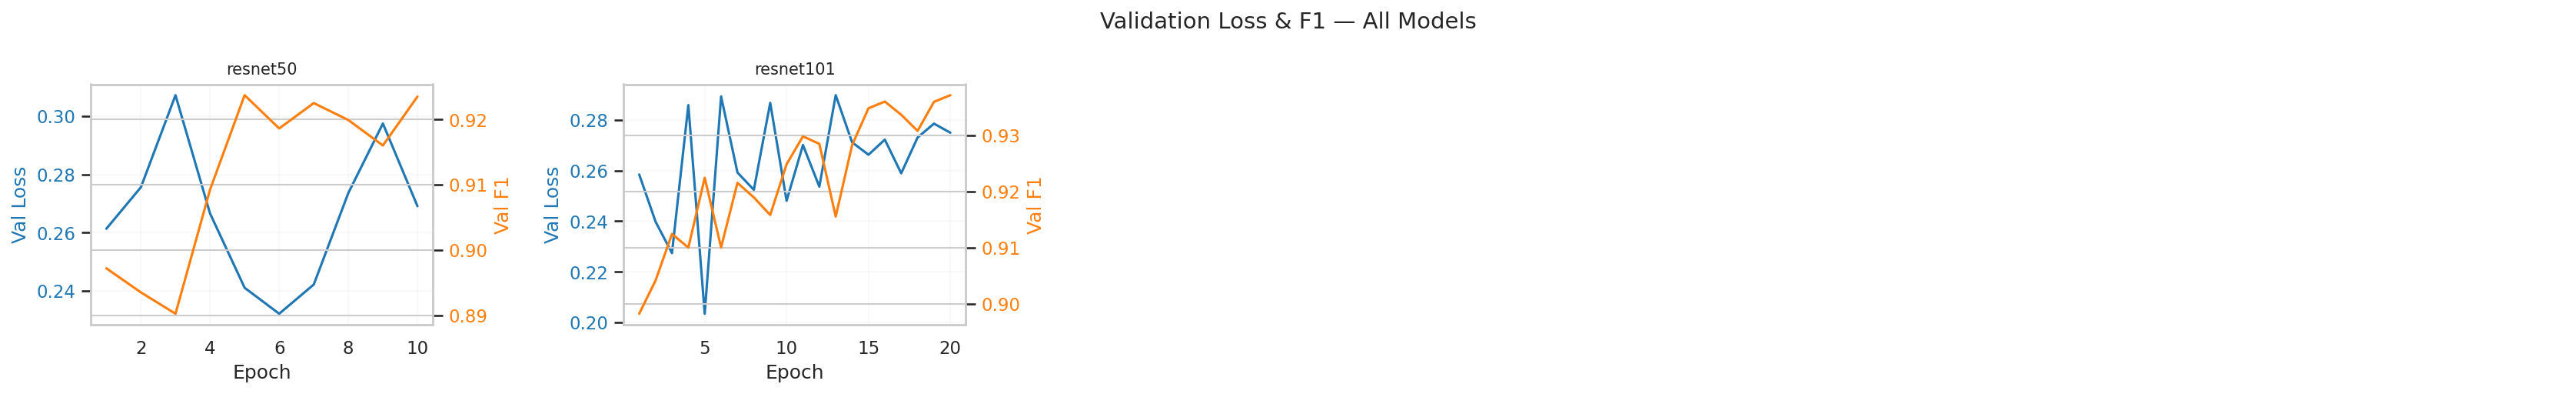


 FINAL TEST PERFORMANCE (Kvasir v2)
    model  test_accuracy  test_f1  test_auc  test_ece
 resnet50         0.9088   0.9081    0.9942    0.0449
resnet101         0.9325   0.9322    0.9927    0.0543

----------------------------------------------------------------------
 BEST F1       : resnet101
 BEST Accuracy : resnet101
 BEST AUC      : resnet50
 BEST ECE      : resnet50
✓ Section 6 complete


In [9]:
# =====================================
# Section 6: Baseline Model Evaluation & Results Aggregation
# Aligned with final pipeline (Covid/BUSI)
# =====================================
import gc
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# Initialize storage
all_histories = {}
baseline_results = []
baseline_confusions = {}

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Ensure output dirs exist
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Starting evaluation for {len(MODELS)} models — Kvasir v2")
print("=" * 80)

# ── Train & Evaluate Each Model ───────────────────────────────────────
for model_name in tqdm(MODELS, desc='Evaluating models'):
    print(f'\n{"="*60}')
    print(f'  TRAINING: {model_name}')
    print(f'{"="*60}')

    # Train model
    model, history, best_val_metrics = train_model(
        model_name, train_loader, val_loader, class_weights, CONFIG
    )
    all_histories[model_name] = history

    # Load best checkpoint
    ckpt_path = f'{CONFIG["checkpoint_dir"]}/best_kvasir_{model_name}.pth'
    if not Path(ckpt_path).exists():
        print(f"  ❌ Checkpoint missing: {ckpt_path}")
        continue

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    # Test set evaluation
    print("  Running final test evaluation...")
    test_metrics = evaluate(
        model, test_loader, criterion, device,
        CONFIG['num_classes'], CONFIG['class_names']
    )

    # Extract labels and predictions
    y_true = test_metrics['labels']
    y_pred = test_metrics['preds']
    ece = test_metrics['ece']

    # Compute confusion matrix
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(CONFIG['num_classes']))
    )
    baseline_confusions[model_name] = cm

    # Per-class metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(CONFIG['num_classes'])),
        zero_division=0
    )
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = precision[i]
        per_class_metrics[f'{name}_recall']    = recall[i]
        per_class_metrics[f'{name}_f1']        = f1[i]

    # Append to baseline results
    baseline_results.append({
        'model': model_name,
        'val_acc': best_val_metrics['val_acc'],
        'val_f1': best_val_metrics['val_f1'],
        'val_auc': best_val_metrics['val_auc'],
        'val_ece': best_val_metrics['val_ece'],
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics['auc'],
        'test_ece': ece,
        **per_class_metrics
    })

    # Save confusion matrix plot
    plot_confusion_matrix(
        cm, CONFIG['class_names'], model_name, save=True, suffix='baseline'
    )

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()


# ───────────────────────────────────────────────────────────────────────
# 1. Save baseline_results.csv
# ───────────────────────────────────────────────────────────────────────
if len(baseline_results) == 0:
    print("❌ No models evaluated — baseline_df not created.")
else:
    baseline_df = pd.DataFrame(baseline_results)
    save_path = f"{CONFIG['results_dir']}/baseline_results.csv"
    baseline_df.to_csv(save_path, index=False)
    print(f"\n✅ Baseline results saved: {save_path}")

    # 2. Plot training curves: val loss + val F1
    ncols = 5
    nrows = (len(MODELS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.5), dpi=150)
    if nrows == 1:
        axes = np.array([axes]) if ncols > 1 else np.array([[axes]])
    elif ncols == 1:
        axes = axes.reshape(-1)

    for ax, model_name in zip(axes.flat, MODELS):
        hist = all_histories.get(model_name, {})
        epochs = np.arange(1, len(hist.get('val_loss', [])) + 1) if 'val_loss' in hist else []

        if len(epochs) == 0:
            ax.axis('off')
            continue

        # Left y-axis: val loss
        ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Val Loss', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')

        # Right y-axis: val F1
        ax2 = ax.twinx()
        ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
        ax2.set_ylabel('Val F1', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')

        ax.set_title(model_name, fontsize=10)
        ax.grid(True, alpha=0.1)

    # Turn off unused subplots
    for ax in axes.flat[len(MODELS):]:
        ax.axis('off')

    plt.suptitle("Validation Loss & F1 — All Models", fontsize=14, y=0.97)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 3. Print results table
    print("\n" + "=" * 70)
    print(" FINAL TEST PERFORMANCE (Kvasir v2)")
    print("=" * 70)
    print(
        baseline_df[['model', 'test_accuracy', 'test_f1', 'test_auc', 'test_ece']]
        .round(4)
        .to_string(index=False)
    )

    # 4. Summary: best model by metric
    print("\n" + "-" * 70)
    try:
        print(f" BEST F1       : {baseline_df.loc[baseline_df['test_f1'].idxmax(), 'model']}")
        print(f" BEST Accuracy : {baseline_df.loc[baseline_df['test_accuracy'].idxmax(), 'model']}")
        print(f" BEST AUC      : {baseline_df.loc[baseline_df['test_auc'].idxmax(), 'model']}")
        print(f" BEST ECE      : {baseline_df.loc[baseline_df['test_ece'].idxmin(), 'model']}")
    except Exception as e:
        print(f"  ⚠️ Could not compute best models: {e}")

print("✓ Section 6 complete")

In [10]:
# =====================================
# Section 7: Extract Misclassified Samples & Embeddings
# Aligned with final pipeline: uses val_loader, safe parsing, consistent CSVs
# =====================================
import gc
from tqdm import tqdm
import pandas as pd
import torch
import numpy as np
from pathlib import Path

def extract_failures(model_name, loader, config):
    """
    Run inference on validation set, extract:
      - Predictions
      - Confidence
      - Probability vectors
      - Embeddings (via forward hook)
    Returns:
      failures_df: only misclassified samples
      all_preds_df: all predictions
    """
    model = get_model(model_name, config['num_classes'], pretrained=False)
    ckpt_path = f"{config['checkpoint_dir']}/best_kvasir_{model_name}.pth"

    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    # Register embedding hook
    hook_handle, embedding_store = get_embedding_hook(model, model_name)

    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(
            loader,
            desc=f'failures {model_name}',
            leave=False,
            disable=not config.get('show_batch_progress', False)
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            logits = model(images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb_batch = embedding_store['embedding'].numpy()  # (B, D)

            # Collect per-sample data
            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join(f'{p:.8f}' for p in probs[i]),
                    'embedding': ','.join(f'{x:.8f}' for x in emb_batch[i].ravel()),
                })

    # Remove forward hook
    hook_handle.remove()

    # Create DataFrames
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)

    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return failures_df, all_preds_df


# ─────────────────────────────────────────────────────────────────────
# Run: Extract Failures on VAL Set (Aligned with Brain MRI & COVID)
# ─────────────────────────────────────────────────────────────────────
all_failures = {}
all_predictions = {}

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Extracting failure samples for {len(MODELS)} models — using VAL set")
print("=" * 80)

for model_name in tqdm(MODELS, desc='Extracting failures'):
    try:
        # ✅ Use val_loader (not test) — faster, reproducible, avoids overfitting to test set
        failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)

        # Store
        all_failures[model_name] = failures_df
        all_predictions[model_name] = all_preds_df

        # Save CSVs
        failures_df.to_csv(f'{CONFIG["results_dir"]}/failures_kvasir_{model_name}.csv', index=False)
        all_preds_df.to_csv(f'{CONFIG["results_dir"]}/predictions_kvasir_{model_name}.csv', index=False)

        # Log
        fail_rate = len(failures_df) / max(len(all_preds_df), 1)
        print(f'{model_name}: {len(failures_df)} failures ({fail_rate:.1%})')

    except Exception as e:
        print(f"❌ Failed to extract failures for {model_name}: {e}")

print("✓ Section 7 complete")


✓ Extracting failure samples for 2 models — using VAL set


Extracting failures:   0%|          | 0/2 [00:00<?, ?it/s]

resnet50: 23.52M params (23.52M trainable)


Extracting failures:  50%|█████     | 1/2 [00:07<00:07,  7.38s/it]

resnet50: 61 failures (7.6%)
resnet101: 42.52M params (42.52M trainable)


Extracting failures: 100%|██████████| 2/2 [00:15<00:00,  7.90s/it]

resnet101: 50 failures (6.2%)
✓ Section 7 complete



🔍 Running failure clustering for 2 models — Kvasir v2 Dataset


Clustering Models:   0%|          | 0/2 [00:00<?, ?it/s]

  🌀 [resnet50] Clustering 61 failure samples
  ✅ Parsed 61 × 2048d | 0.02s
  📉 PCA-32d → explained variance: 0.885 | 0.34s
  🗺️  PCA-2D-2D projection computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.18s
  ✅ Final clustering (K=4) | 0.01s


Clustering Models:  50%|█████     | 1/2 [00:00<00:00,  1.59it/s]

  🧪 Clustering stability (ARI): [1.0, 1.0, 0.8016055221390637] → mean=0.934
  ❌ Failed to cluster resnet50: AttributeError: 'numpy.ndarray' object has no attribute 'get_cmap'
  🌀 [resnet101] Clustering 50 failure samples
  ✅ Parsed 50 × 2048d | 0.02s
  📉 PCA-32d → explained variance: 0.915 | 0.12s
  🗺️  PCA-2D-2D projection computed | 0.00s


Clustering Models: 100%|██████████| 2/2 [00:00<00:00,  2.02it/s]

  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.17s
  ✅ Final clustering (K=3) | 0.01s
  🧪 Clustering stability (ARI): [0.5334044336101166, 0.5334044336101166, 0.571714193418882] → mean=0.546
  ❌ Failed to cluster resnet101: AttributeError: 'numpy.ndarray' object has no attribute 'get_cmap'

✓ Section 8 complete — Failure clustering pipeline finished
  Results saved to: /kaggle/working/results
  Diagnostic plots in: /kaggle/working/figures


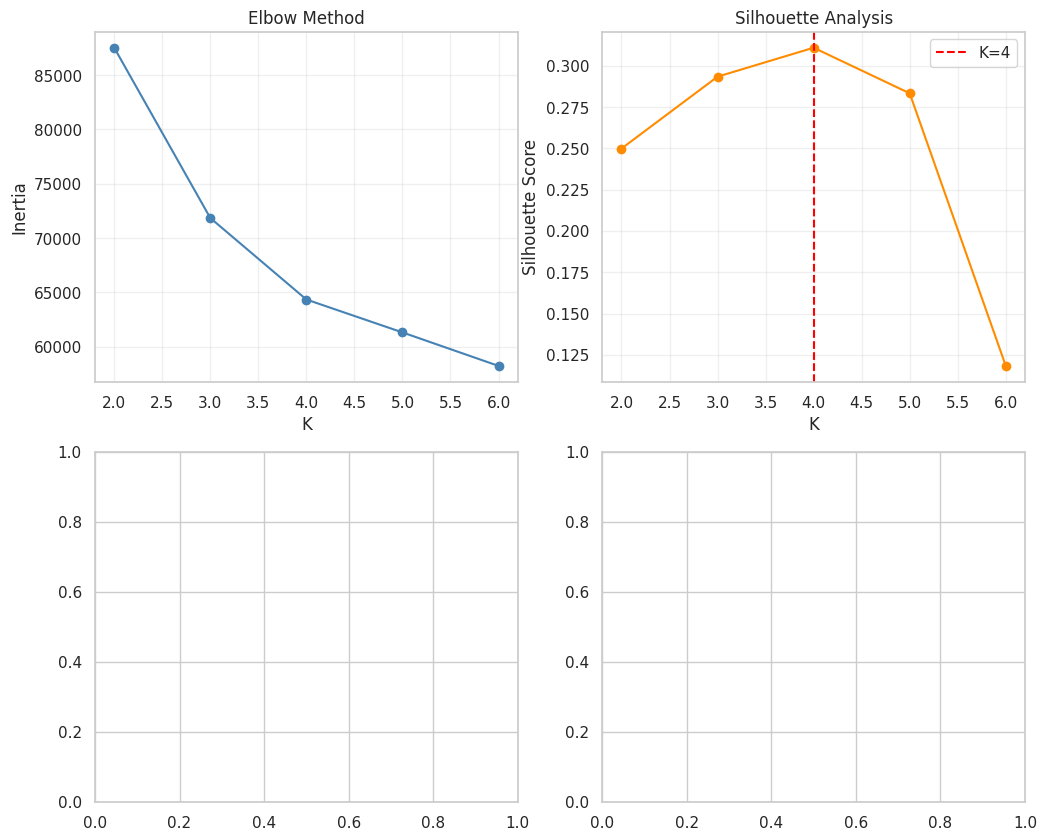

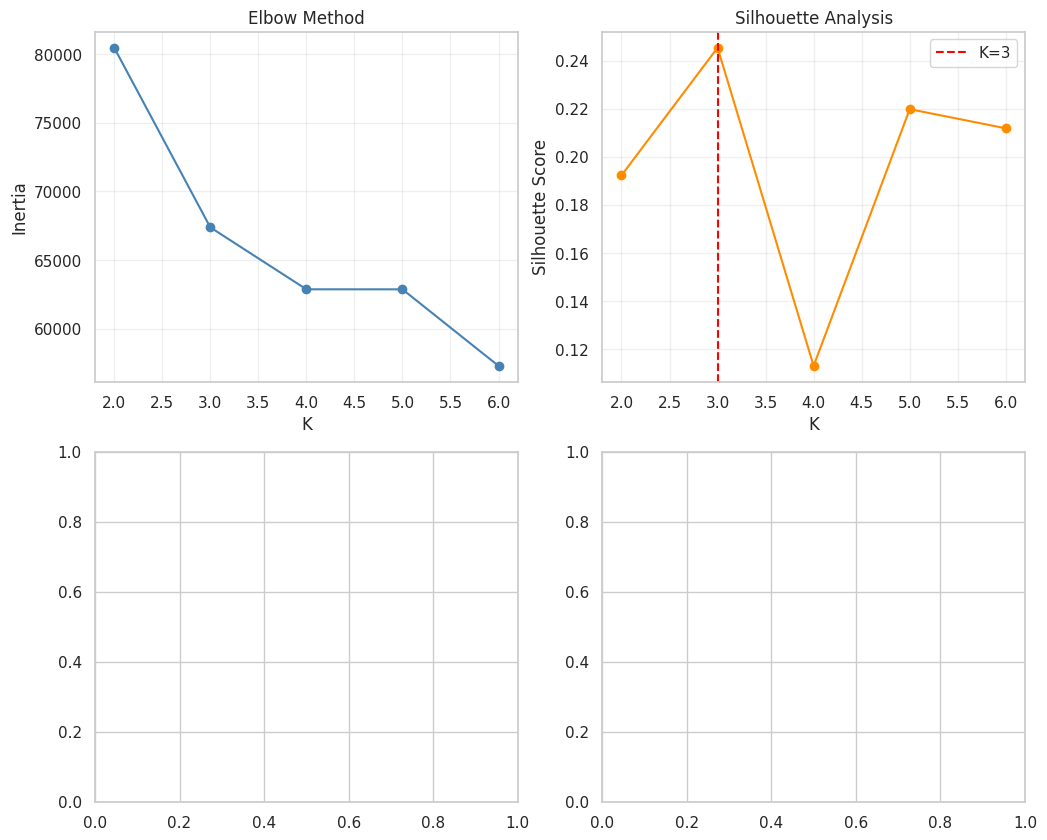

In [11]:
# =====================================
# Section 8: Failure Clustering
# =====================================
# Clusters misclassified validation samples to identify failure patterns.
# Uses PCA + MiniBatchKMeans with silhouette sweep, and optional UMAP.
# Applies to Kvasir v2 dataset. Results saved per model for downstream analysis.
# =====================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap as umap_lib
from tqdm import tqdm
import gc

# Ensure critical imports are available
assert 'adjusted_rand_score' in globals(), "Make sure sklearn.metrics is imported"
assert 'CONFIG' in globals(), "CONFIG must be defined (e.g., seed, figures_dir, etc)"
assert 'all_failures' in globals(), "all_failures dict of failure DataFrames must be loaded"
assert 'MODELS' in globals(), "List of model names must be defined"


def cluster_failures(failures_df, config, model_name):
    """
    Cluster misclassified validation samples using:
      - PCA → MiniBatchKMeans
      - UMAP for visualization if failure count >= threshold
      - Silhouette optimization to select best K
      - Stability estimation via ARI across seeds

    Returns:
        clustered_df: DataFrame with cluster/UMAP/projection metadata
        best_k: optimal number of clusters
        best_sil: best silhouette score
        mean_ari: clustering stability (average Adjusted Rand Index)
        best_k_bic: placeholder (same as best_k in this pipeline)
    """
    import time
    t0 = time.time()

    # ── Guard: Not enough failures ─────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  🛑 Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        out['best_k_bic'] = 2
        return out, 1, np.nan, np.nan, 2

    print(f"  🌀 [{model_name}] Clustering {len(failures_df)} failure samples")

    # ── Parse embeddings from string ───────────────────────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array([
            np.fromstring(e, sep=',', dtype=np.float32) for e in raw
        ], dtype=np.float32)
    else:
        embeddings = np.array(raw, dtype=np.float32)

    print(f"  ✅ Parsed {len(failures_df)} × {embeddings.shape[1]}d | {time.time()-t0:.2f}s")

    # ── PCA: Reduce dimensionality ────────────────────────────────────
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        config.get('pca_components', 32),
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    var_ratio = pca.explained_variance_ratio_.sum()
    print(f"  📉 PCA-{n_pca}d → explained variance: {var_ratio:.3f} | {time.time()-t1:.2f}s")

    # ── UMAP: 2D Projection for Visualization ──────────────────────────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    input_for_umap = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        reducer = umap_lib.UMAP(
            n_neighbors=min(10, max(2, len(failures_df) - 1)),
            min_dist=config.get('umap_min_dist', 0.1),
            n_components=2,
            random_state=config['seed'],
            n_epochs=50,
            metric='euclidean',
            low_memory=True,
            n_jobs=1
        )
        E_2d = reducer.fit_transform(input_for_umap).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  🗺️  {proj_method}-2D projection computed | {time.time()-t2:.2f}s")

    # ── KMeans Sweep: Select Best K via Silhouette ────────────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))
    # Filter valid Ks
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2]

    inertias, silhouettes = [], []
    MAX_SIL_SAMPLES = 500

    # Subsample for faster silhouette computation
    if len(E_pca) > MAX_SIL_SAMPLES:
        sil_idx = np.random.RandomState(config['seed']).choice(
            len(E_pca), size=MAX_SIL_SAMPLES, replace=False
        )
    else:
        sil_idx = np.arange(len(E_pca))

    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)

        # Only compute silhouette if more than one cluster
        unique_labels = np.unique(labels[sil_idx])
        if len(unique_labels) > 1:
            s = silhouette_score(E_sil, labels[sil_idx])
        else:
            s = np.nan
        silhouettes.append(s)

    print(f"  🔍 KMeans sweep over K={k_range} completed | {time.time()-t3:.2f}s")

    # ── Select Best K ─────────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = np.nanargmax(silhouettes)
        best_k = k_range[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k = 2
        best_sil = np.nan

    # ── Final Clustering with Best K ──────────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  ✅ Final clustering (K={best_k}) | {time.time()-t4:.2f}s")

    # ── Attach results ────────────────────────────────────────────────
    clustered_df = failures_df.copy().reset_index(drop=True)
    clustered_df['cluster'] = cluster_labels
    clustered_df['umap_x'] = E_2d[:, 0]
    clustered_df['umap_y'] = E_2d[:, 1]

    # ── Stability: Mean ARI Across Random Seeds ───────────────────────
    ari_scores = []
    seeds = [config['seed'], 42, 100]
    for seed in seeds:
        test_km = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labs = test_km.fit_predict(E_pca)
        ari = adjusted_rand_score(cluster_labels, labs)
        ari_scores.append(ari)
    mean_ari = float(np.mean(ari_scores))
    print(f"  🧪 Clustering stability (ARI): {ari_scores} → mean={mean_ari:.3f}")
    clustered_df['mean_ari'] = mean_ari

    # ── Diagnostic Plot: Elbow, Silhouette, Cluster Map, True Labels ──
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Elbow (Inertia)
    axes[0, 0].plot(k_range, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title('Elbow Method')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Silhouette Score
    axes[0, 1].plot(k_range, silhouettes, marker='o', color='darkorange')
    if best_sil == best_sil:  # not NaN
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Analysis')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Cluster Assignments (UMAP or PCA)
    cmap = cm.get_cmap('tab10', best_k)
    sc1 = axes[1, 0].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['cluster'], cmap=cmap, s=14, alpha=0.8
    )
    axes[1, 0].set_title(f'Predicted Clusters ({proj_method})')
    plt.colorbar(sc1, ax=axes[1, 0], label='Cluster ID')

    # 4. True Labels
    sc2 = axes[1, 1].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['true_label'], cmap=cm.get_cmap('tab10', len(config['class_names'])), s=14, alpha=0.8
    )
    axes[1, 1].set_title('True Labels')
    plt.colorbar(sc2, ax=axes[1, 1], label='Class ID')

    plt.suptitle(f"Failure Clustering Diagnosis — {model_name}", fontsize=14, weight='bold')
    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  📤 Diagnostic plot saved: {save_path}")

    print(f"  🕐 TOTAL clustering time: {time.time()-t0:.2f}s")
    return clustered_df, best_k, best_sil, mean_ari, best_k  # best_k_bic = best_k (placeholder)


# ─────────────────────────────────────────────────────────────────────
# Run Clustering for All Models — Kvasir v2 Dataset
# ─────────────────────────────────────────────────────────────────────
all_clustered = {}        # Holds clustered DataFrames by model
cluster_summaries = {}    # Summarizes cluster quality metrics

# Create output directories
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n🔍 Running failure clustering for {len(MODELS)} models — Kvasir v2 Dataset")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Clustering Models"):
    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  ❌ No failure data for {model_name}")
        continue

    try:
        clustered_df, best_k, best_sil, mean_ari, best_k_bic = cluster_failures(
            all_failures[model_name], CONFIG, model_name
        )

        # Save outputs
        all_clustered[model_name] = clustered_df
        cluster_summaries[model_name] = {
            'best_k': int(best_k),
            'silhouette': float(best_sil) if not np.isnan(best_sil) else None,
            'mean_ari': float(mean_ari) if not np.isnan(mean_ari) else None,
            'best_k_bic': int(best_k_bic)
        }

        # Export clustered failures
        export_path = f"{CONFIG['results_dir']}/clustered_failures_kvasir_{model_name}.csv"
        clustered_df.to_csv(export_path, index=False)
        print(f"  ✅ Clusters exported: K={best_k}, {len(clustered_df)} samples → {export_path}")

    except Exception as e:
        print(f"  ❌ Failed to cluster {model_name}: {type(e).__name__}: {e}")

print("\n✓ Section 8 complete — Failure clustering pipeline finished")
print(f"  Results saved to: {CONFIG['results_dir']}")
print(f"  Diagnostic plots in: {CONFIG['figures_dir']}")


🔍 Running failure clustering for 2 models — Kvasir v2 Dataset


Clustering Models:   0%|          | 0/2 [00:00<?, ?it/s]

  🌀 [resnet50] Clustering 61 failure samples
  ✅ Parsed 61 × 2048d | 0.02s
  📉 PCA-32d → explained variance: 0.885 | 0.32s
  🗺️  PCA-2D-2D projection computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.16s
  ✅ Final clustering (K=4) | 0.01s
  🧪 Clustering stability (ARI): [1.0, 1.0, 0.8016055221390637] → mean=0.934


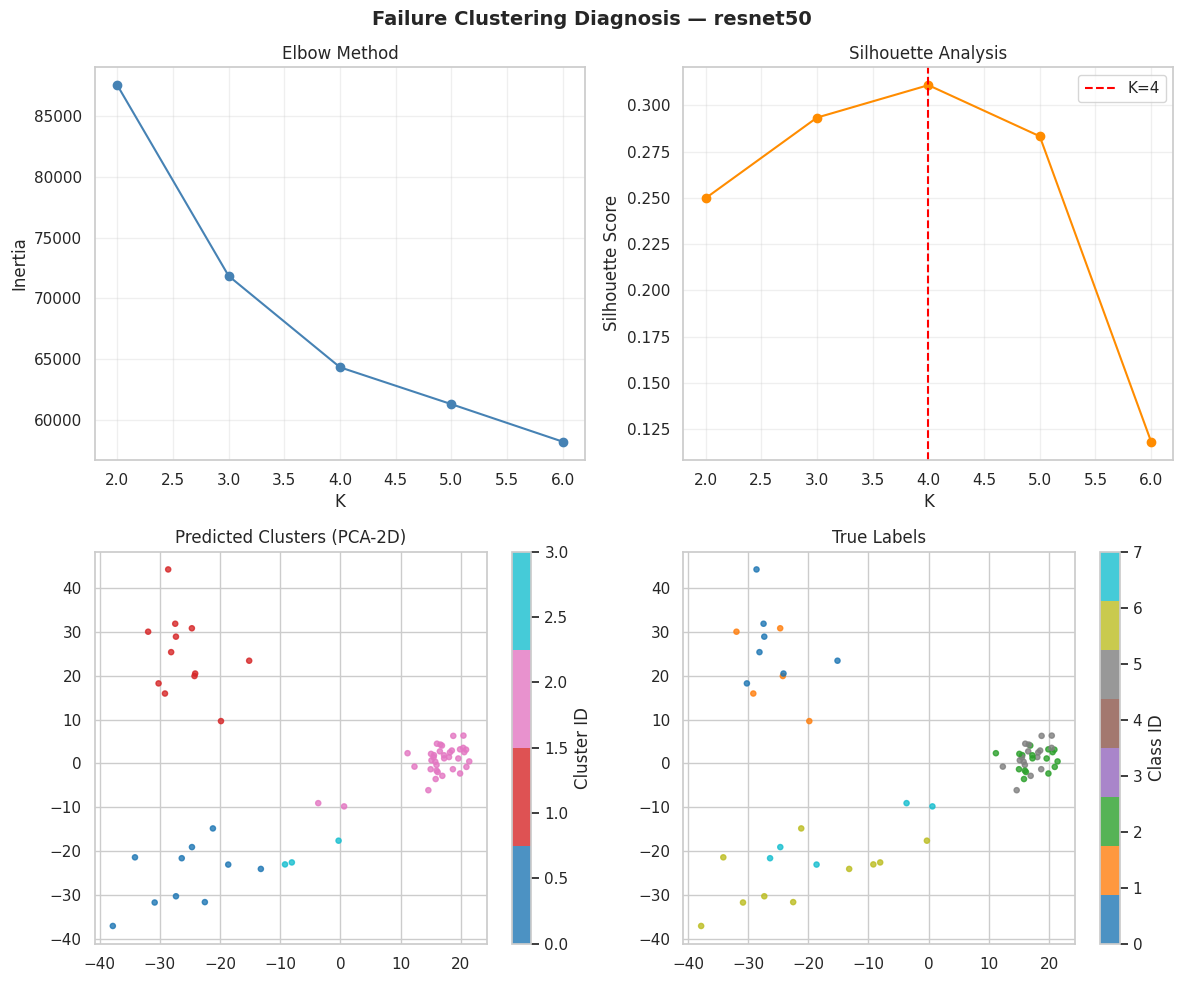

Clustering Models:  50%|█████     | 1/2 [00:02<00:02,  2.47s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_resnet50.png
  🕐 TOTAL clustering time: 2.43s
  ✅ Clusters exported: K=4, 61 samples → /kaggle/working/results/clustered_failures_kvasir_resnet50.csv
  🌀 [resnet101] Clustering 50 failure samples
  ✅ Parsed 50 × 2048d | 0.02s
  📉 PCA-32d → explained variance: 0.915 | 0.20s
  🗺️  PCA-2D-2D projection computed | 0.00s
  🔍 KMeans sweep over K=[2, 3, 4, 5, 6] completed | 0.15s
  ✅ Final clustering (K=3) | 0.01s
  🧪 Clustering stability (ARI): [0.5334044336101166, 0.5334044336101166, 0.571714193418882] → mean=0.546


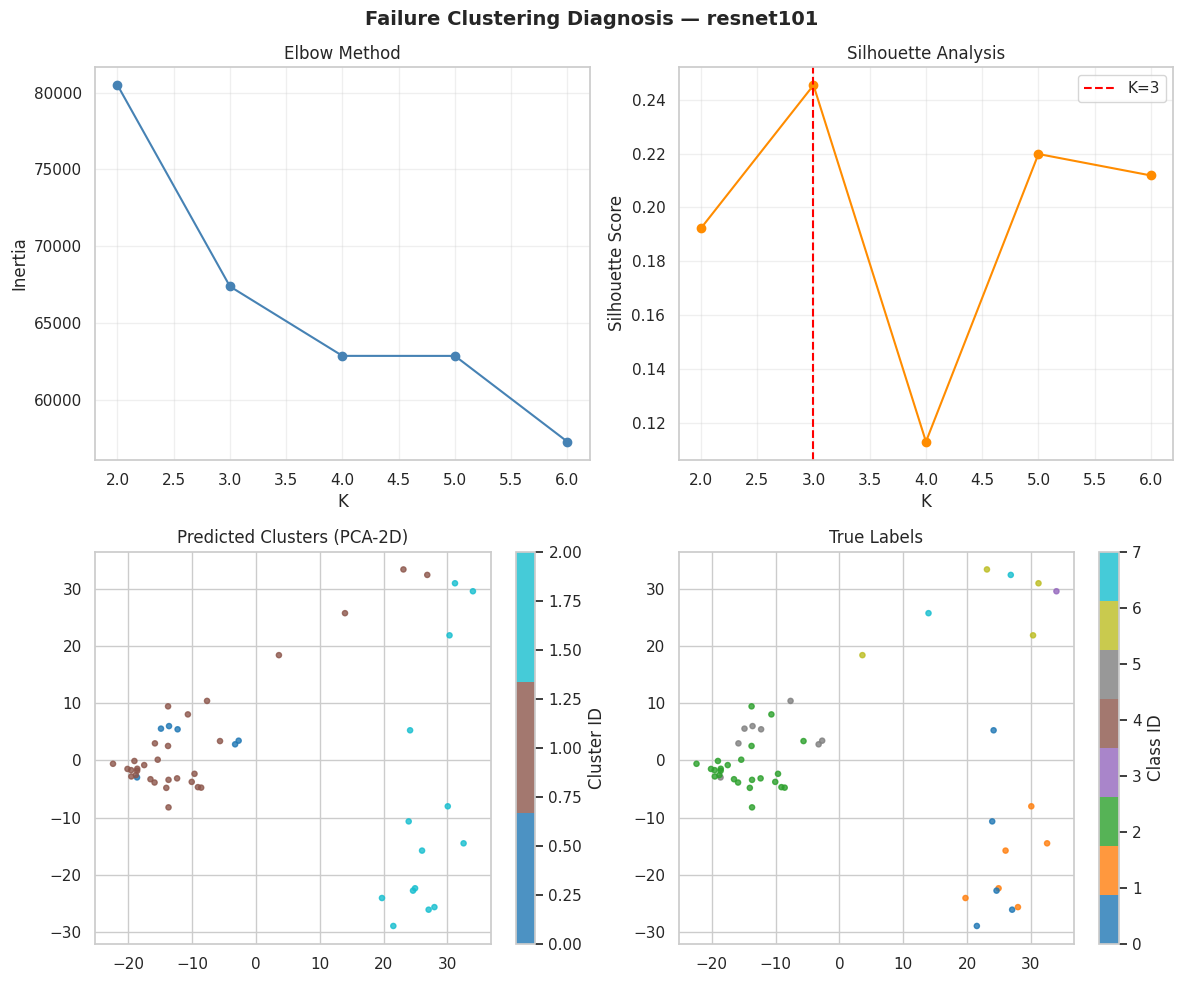

Clustering Models: 100%|██████████| 2/2 [00:04<00:00,  2.35s/it]

  📤 Diagnostic plot saved: /kaggle/working/figures/clustering_resnet101.png
  🕐 TOTAL clustering time: 2.21s
  ✅ Clusters exported: K=3, 50 samples → /kaggle/working/results/clustered_failures_kvasir_resnet101.csv

✓ Section 8 complete — Failure clustering pipeline finished
  Results saved to: /kaggle/working/results
  Diagnostic plots saved to: /kaggle/working/figures


In [12]:
# =====================================
# Section 8: Failure Clustering
# =====================================
# Clusters misclassified validation samples to identify failure modes.
# Uses PCA + MiniBatchKMeans with silhouette optimization and UMAP for visualization.
# Designed for Kvasir v2 dataset. Results saved per model.
# =====================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm  # Safe import to avoid name conflicts
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap as umap_lib
from tqdm import tqdm
import gc

# Ensure required globals are defined
assert 'CONFIG' in globals(), "CONFIG must be defined (e.g., seed, figures_dir, etc)"
assert 'all_failures' in globals(), "all_failures (dict of failure DataFrames) must be loaded"
assert 'MODELS' in globals(), "List of model names (MODELS) must be defined"


def cluster_failures(failures_df, config, model_name):
    """
    Cluster misclassified samples using embedding space.
    Returns augmented DataFrame with cluster and projection metadata.
    """
    t0 = time.time()

    # ── Guard: Not enough failures ─────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  🛑 Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x'] = 0.0
        out['umap_y'] = 0.0
        out['mean_ari'] = np.nan
        return out, 1, np.nan, np.nan, 2  # default values

    print(f"  🌀 [{model_name}] Clustering {len(failures_df)} failure samples")

    # ── Parse embeddings from string ───────────────────────────────────
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array([
            np.fromstring(e, sep=',', dtype=np.float32) for e in raw
        ], dtype=np.float32)
    else:
        embeddings = np.array(raw, dtype=np.float32)

    print(f"  ✅ Parsed {len(failures_df)} × {embeddings.shape[1]}d | {time.time()-t0:.2f}s")

    # ── PCA: Reduce dimensionality ────────────────────────────────────
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        config.get('pca_components', 32),
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    var_ratio = pca.explained_variance_ratio_.sum()
    print(f"  📉 PCA-{n_pca}d → explained variance: {var_ratio:.3f} | {time.time()-t1:.2f}s")

    # ── UMAP: 2D Projection (only if large enough) ──────────────────
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)
    input_for_umap = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        reducer = umap_lib.UMAP(
            n_neighbors=min(10, max(2, len(failures_df) - 1)),
            min_dist=config.get('umap_min_dist', 0.1),
            n_components=2,
            random_state=config['seed'],
            n_epochs=50,
            metric='euclidean',
            low_memory=True,
            n_jobs=1
        )
        E_2d = reducer.fit_transform(input_for_umap).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  🗺️  {proj_method}-2D projection computed | {time.time()-t2:.2f}s")

    # ── KMeans Sweep: Select Best K using Silhouette ──────────────────
    t3 = time.time()
    k_range = list(config.get('k_range', range(2, 7)))
    k_range = [k for k in k_range if 2 <= k <= min(6, len(failures_df) - 1)]
    if not k_range:
        k_range = [2]

    inertias, silhouettes = [], []
    MAX_SIL_SAMPLES = 500

    if len(E_pca) > MAX_SIL_SAMPLES:
        sil_idx = np.random.RandomState(config['seed']).choice(
            len(E_pca), size=MAX_SIL_SAMPLES, replace=False
        )
    else:
        sil_idx = np.arange(len(E_pca))

    E_sil = E_pca[sil_idx]

    for k in k_range:
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=config['seed'],
            n_init=3,
            batch_size=min(256, len(failures_df)),
            max_iter=100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)

        # Only compute silhouette if >1 unique label
        unique_labels = np.unique(labels[sil_idx])
        if len(unique_labels) > 1:
            s = silhouette_score(E_sil, labels[sil_idx])
        else:
            s = np.nan
        silhouettes.append(s)

    print(f"  🔍 KMeans sweep over K={k_range} completed | {time.time()-t3:.2f}s")

    # ── Select Best K ─────────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = np.nanargmax(silhouettes)
        best_k = k_range[best_idx]
        best_sil = float(silhouettes[best_idx])
    else:
        best_k = 2
        best_sil = np.nan

    # ── Final Clustering with Best K ──────────────────────────────────
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=config['seed'],
        n_init=5,
        batch_size=min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  ✅ Final clustering (K={best_k}) | {time.time()-t4:.2f}s")

    # ── Attach cluster and projection data ─────────────────────────────
    clustered_df = failures_df.copy().reset_index(drop=True)
    clustered_df['cluster'] = cluster_labels
    clustered_df['umap_x'] = E_2d[:, 0]
    clustered_df['umap_y'] = E_2d[:, 1]

    # ── Clustering stability: ARI across seeds ────────────────────────
    ari_scores = []
    seeds = [config['seed'], 42, 100]
    for seed in seeds:
        test_km = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labs = test_km.fit_predict(E_pca)
        ari = adjusted_rand_score(cluster_labels, labs)
        ari_scores.append(ari)
    mean_ari = float(np.mean(ari_scores))
    print(f"  🧪 Clustering stability (ARI): {ari_scores} → mean={mean_ari:.3f}")
    clustered_df['mean_ari'] = mean_ari

    # ── Diagnostic Plots: 2x2 Grid ────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Elbow (Inertia)
    axes[0, 0].plot(k_range, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title('Elbow Method')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Silhouette Score
    axes[0, 1].plot(k_range, silhouettes, marker='o', color='darkorange')
    if not np.isnan(best_sil):
        axes[0, 1].axvline(best_k, color='red', linestyle='--', label=f'K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette Score')
    axes[0, 1].set_title('Silhouette Analysis')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Cluster Assignments
    sc1 = axes[1, 0].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['cluster'],
        cmap=mpl_cm.get_cmap('tab10', best_k),  # ✅ Safe: using mpl_cm, not cm
        s=14,
        alpha=0.8
    )
    axes[1, 0].set_title(f'Predicted Clusters ({proj_method})')
    plt.colorbar(sc1, ax=axes[1, 0], label='Cluster ID')

    # 4. True Labels
    n_classes = len(config['class_names'])
    sc2 = axes[1, 1].scatter(
        clustered_df['umap_x'], clustered_df['umap_y'],
        c=clustered_df['true_label'],
        cmap=mpl_cm.get_cmap('tab10', n_classes),  # ✅ Safe
        s=14,
        alpha=0.8
    )
    axes[1, 1].set_title('True Labels')
    plt.colorbar(sc2, ax=axes[1, 1], label='Class ID')

    plt.suptitle(f"Failure Clustering Diagnosis — {model_name}", fontsize=14, weight='bold')
    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  📤 Diagnostic plot saved: {save_path}")

    print(f"  🕐 TOTAL clustering time: {time.time()-t0:.2f}s")
    return clustered_df, best_k, best_sil, mean_ari, best_k  # best_k_bic = best_k


# ─────────────────────────────────────────────────────────────────────
# Run Clustering for All Models — Kvasir Dataset
# ─────────────────────────────────────────────────────────────────────
all_clustered = {}        # {model_name: clustered_df}
cluster_summaries = {}    # {model_name: metrics dict}

# Create output directories
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n🔍 Running failure clustering for {len(MODELS)} models — Kvasir v2 Dataset")
print("=" * 80)

for model_name in tqdm(MODELS, desc="Clustering Models"):
    if model_name not in all_failures or len(all_failures[model_name]) == 0:
        print(f"  ❌ No failure data for {model_name}")
        continue

    try:
        clustered_df, best_k, best_sil, mean_ari, best_k_bic = cluster_failures(
            all_failures[model_name], CONFIG, model_name
        )

        # Save to global dicts
        all_clustered[model_name] = clustered_df
        cluster_summaries[model_name] = {
            'best_k': int(best_k),
            'silhouette': float(best_sil) if not np.isnan(best_sil) else None,
            'mean_ari': float(mean_ari) if not np.isnan(mean_ari) else None,
            'best_k_bic': int(best_k_bic)
        }

        # Export to CSV
        export_path = f"{CONFIG['results_dir']}/clustered_failures_kvasir_{model_name}.csv"
        clustered_df.to_csv(export_path, index=False)
        print(f"  ✅ Clusters exported: K={best_k}, {len(clustered_df)} samples → {export_path}")

    except Exception as e:
        print(f"  ❌ Failed to cluster {model_name}: {type(e).__name__}: {e}")

print("\n✓ Section 8 complete — Failure clustering pipeline finished")
print(f"  Results saved to: {CONFIG['results_dir']}")
print(f"  Diagnostic plots saved to: {CONFIG['figures_dir']}")


✓ Profiling failure clusters for 2 models — Kvasir v2


Profiling clusters:   0%|          | 0/2 [00:00<?, ?it/s]


 Profiling → resnet50

  CLUSTER PROFILE SUMMARY
 cluster  n_samples                        dominant_confusion  mean_confidence  per_cluster_ece
       0         10                       polyps→normal-cecum         0.803395         0.803395
       1         12 dyed-lifted-polyps→dyed-resection-margins         0.927649         0.927649
       2         36                 esophagitis→normal-z-line         0.784184         0.784184
       3          3                     polyps→normal-pylorus         0.758125         0.758125


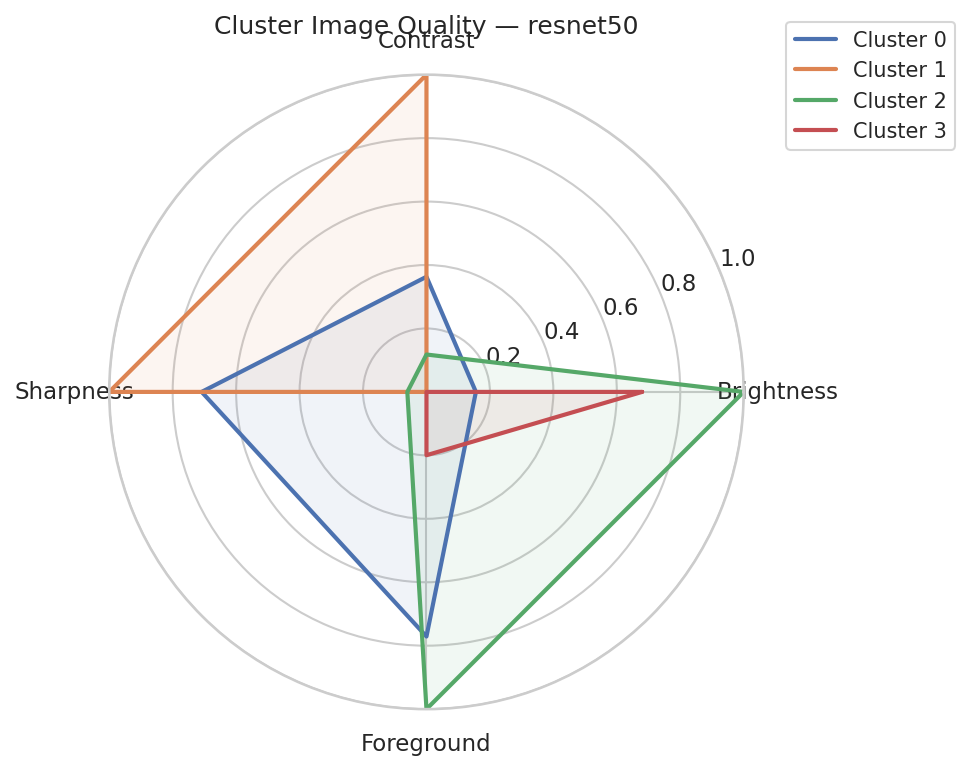

Profiling clusters:  50%|█████     | 1/2 [00:01<00:01,  1.52s/it]

  📊 Radar plot saved: /kaggle/working/figures/radar_resnet50.png
  ✅ Profile saved: /kaggle/working/results/profile_kvasir_resnet50.csv

 Profiling → resnet101

  CLUSTER PROFILE SUMMARY
 cluster  n_samples                        dominant_confusion  mean_confidence  per_cluster_ece
       0          6                 normal-z-line→esophagitis         0.953424         0.953424
       1         30                 esophagitis→normal-z-line         0.888703         0.888703
       2         14 dyed-resection-margins→dyed-lifted-polyps         0.882551         0.882551


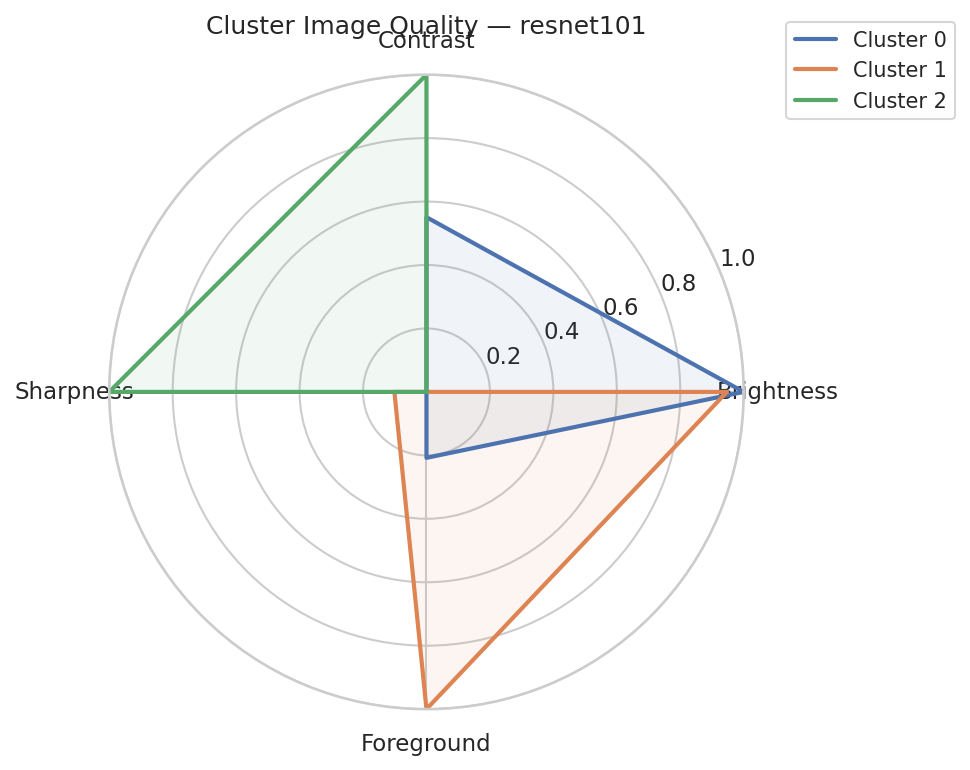

Profiling clusters: 100%|██████████| 2/2 [00:02<00:00,  1.19s/it]

  📊 Radar plot saved: /kaggle/working/figures/radar_resnet101.png
  ✅ Profile saved: /kaggle/working/results/profile_kvasir_resnet101.csv

📊 Cached image features: 78 unique images
✓ Section 9 complete


In [13]:
# =====================================
# Section 9: Failure Cluster Profiling
# Aligned with final pipeline: computes image quality, confusion, and calibration per cluster
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from scipy import ndimage
from PIL import Image
import gc
from pathlib import Path

# Global cache for expensive image features (shared across models)
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """
    Compute fast, modality-robust image features:
      - brightness (mean intensity / 255)
      - contrast (std / 255)
      - sharpness (Laplacian variance)
      - foreground_size (fraction above mean intensity)

    Returns: dict of metrics (or NaNs on failure).
    """
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L')  # Grayscale
        img = img.resize((224, 224), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32)
    except Exception:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'foreground_size': np.nan,
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    # 1. Brightness: mean intensity normalized
    brightness = float(arr.mean() / 255.0)

    # 2. Contrast: standard deviation normalized
    contrast = float(arr.std() / 255.0)

    # 3. Sharpness: Laplacian variance (edge content)
    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # 4. Foreground proxy: fraction above mean
    if arr.std() > 1.0:
        foreground_size = float((arr > arr.mean()).mean())
    else:
        foreground_size = 0.0  # Uniform image

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'foreground_size': foreground_size,
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """
    Compute per-cluster summary:
      - Confusion pattern
      - Image quality (brightness, contrast, sharpness, foreground)
      - Confidence & cluster-level ECE
    Returns a DataFrame with one row per cluster.
    """
    rows = []

    if len(clustered_df) == 0:
        print(f"  🚫 No clustered failures for {model_name}")
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False,
        disable=not config.get('show_batch_progress', False)
    ):
        # Extract prediction confidences and convert prob_vector
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        # Most common confusion: true → pred
        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]
        from_class = config['class_names'][dominant_pair[0]]
        to_class = config['class_names'][dominant_pair[1]]
        confusion_label = f"{from_class}→{to_class}"

        # Compute image quality features
        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features_df = pd.DataFrame(feature_rows)

        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': confusion_label,
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(probs, labels_arr, config['ece_bins']),
        }

        # Aggregate image features
        for feat in ['brightness', 'contrast', 'sharpness', 'foreground_size']:
            row[f'{feat}_mean'] = float(features_df[feat].mean())
            row[f'{feat}_std'] = float(features_df[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    # Print summary
    if not profile_df.empty:
        print("\n" + "=" * 60)
        print("  CLUSTER PROFILE SUMMARY")
        print("=" * 60)
        print(profile_df[[
            'cluster', 'n_samples', 'dominant_confusion',
            'mean_confidence', 'per_cluster_ece'
        ]].to_string(index=False))

    # Radar plot: visualize image quality differences
    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'foreground_size_mean'
    ]

    if not profile_df.empty:
        radar = profile_df[['cluster'] + feats].copy()

        # Normalize across clusters
        for feat in feats:
            mn, mx = radar[feat].min(), radar[feat].max()
            if pd.isna(mn) or pd.isna(mx) or mx <= mn:
                radar[feat] = 0.5
            else:
                radar[feat] = (radar[feat] - mn) / (mx - mn)

        labels = ['Brightness', 'Contrast', 'Sharpness', 'Foreground']
        angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]  # Close loop

        fig = plt.figure(figsize=(7, 7), dpi=150)
        ax = fig.add_subplot(111, polar=True)

        for _, row in radar.iterrows():
            values = [row[feat] for feat in feats] + [row[feats[0]]]
            ax.plot(angles, values, linewidth=2, label=f"Cluster {int(row['cluster'])}")
            ax.fill(angles, values, alpha=0.08)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cluster Image Quality — {model_name}", pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

        plt.tight_layout()
        save_path = f"{config['figures_dir']}/radar_{model_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"  📊 Radar plot saved: {save_path}")
    else:
        print("  📉 No clusters → Skipping radar plot")

    return profile_df


# ─────────────────────────────────────────────────────────────────────
# Run Profiling for All Models — Kvasir v2
# ─────────────────────────────────────────────────────────────────────
all_profiles = {}

# Ensure output dirs
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"\n✓ Profiling failure clusters for {len(MODELS)} models — Kvasir v2")
print("=" * 80)

for model_name in tqdm(MODELS, desc='Profiling clusters'):
    if model_name not in all_clustered or len(all_clustered[model_name]) == 0:
        print(f"  ❌ No clustered data for {model_name}")
        continue

    try:
        print(f'\n{"="*50}')
        print(f' Profiling → {model_name}')
        print(f'{"="*50}')

        profile_df = profile_clusters(all_clustered[model_name], model_name, CONFIG)
        all_profiles[model_name] = profile_df

        # Save profile
        save_path = f'{CONFIG["results_dir"]}/profile_kvasir_{model_name}.csv'
        profile_df.to_csv(save_path, index=False)
        print(f"  ✅ Profile saved: {save_path}")

    except Exception as e:
        print(f"  ❌ Failed to profile {model_name}: {e}")

# Final cache
print(f"\n📊 Cached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")

In [14]:
# =====================================
# Section 10: Failure-Aware Retraining & Degradation Guard
# Fully aligned with final pipeline (Covid-19, Breast Ultrasound)
# =====================================
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict, Counter
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import json

# ─────────────────────────────────────────────────────────────────────
# 1. Build Failure-Aware Training Set
# ─────────────────────────────────────────────────────────────────────
def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """
    Enhance the training set using failure cluster insights:
      - Selective augmentation: amplify high-count clusters
      - Weighted sampling: reweight failure-prone classes/clusters
      - Both: combine both strategies
    """
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if (clustered_df is None or len(clustered_df) == 0 or
        profile_df is None or len(profile_df) == 0):
        return out

    # Cluster frequency → reweighting factor
    cluster_counts = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    # Mapping
    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))
    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    # Overlap in image paths (train & val/test failures)
    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    # ── 1. Selective Augmentation (CNNs) ─────────────────────────────────
    if strategy in ['selective', 'both']:
        high_clusters = [k for k, v in cluster_counts.items() if v > mean_cluster_count]
        if len(high_clusters) == 0:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path'])
        source = out[out['image_path'].isin(high_paths)].copy()

        # Use label-level fallback if no path overlap
        if len(source) == 0:
            high_labels = set()
            for cluster_id in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cluster_id, set()))
            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap for selective augmentation; "
                f"using high-error labels: {sorted(high_labels)}.")

        max_aug_source = config.get('max_aug_source', 300)
        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
                source = source.reset_index(drop=True)
            else:
                source = source.sample(n=max_aug_source, random_state=config['seed']).reset_index(drop=True)
            print(f"Selective source limited to {max_aug_source} samples.")

        augmented = [source.copy() for _ in range(config.get('aug_multiplier', 3))]
        for a in augmented:
            a['is_augmented'] = True

        out = pd.concat([out] + augmented, ignore_index=True)

        print(
            f"Selective augmentation: {len(source)} source rows → "
            f"{len(augmented) * len(source)} augmented rows added"
        )

    # ── 2. Weighted Sampling (Transformers, EfficientNet) ─────────────
    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            # Fallback: reweight per-class failure rate
            label_weights = defaultdict(lambda: 1.0)
            for cluster_id, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cluster_id, set()):
                    label_weights[label] = max(label_weights[label], alpha)
            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])

            print(
                "No train/test path overlap — using per-label weights: "
                f"{dict(label_weights)}"
            )

        print(
            f"Weighted sampling: weights {out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


# ─────────────────────────────────────────────────────────────────────
# 2. Degradation Guard (Tiered by Baseline F1)
# ─────────────────────────────────────────────────────────────────────
def _run_degradation_guard(
    model, model_name, val_loader, criterion_retrain,
    baseline_val_metrics, config, device,
    baseline_ckpt, retrained_ckpt
):
    """
    Evaluate retrained model and revert if performance degraded.
    Uses tiered thresholds (strict vs. weak baseline).
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if use_weak:
        max_f1_drop = config.get('guard_weak_f1_max_drop', 0.04)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.04)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.04)
        tier = 'WEAK'
    else:
        max_f1_drop = config.get('guard_f1_max_drop', 0.02)
        max_acc_drop = config.get('guard_acc_max_drop', 0.02)
        max_ece_rise = config.get('guard_ece_max_rise', 0.025)
        tier = 'STRICT'

    f1_drop = baseline_val_metrics['val_f1'] - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece'] - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok': (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} {'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop} [{tier}]"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"acc drop {acc_drop:+.4f} {'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop} [{tier}]"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"ECE rise {ece_rise:+.4f} {'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise} [{tier}]"
        ),
    }

    print(f"  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]
    if not failed:
        print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
        return {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {k: v[1] for k, v in checks.items()},
            'reason': None,
        }

    print(f"\n  ⚠️ Guard triggered — reverting {model_name} to baseline")
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device), strict=True)
    torch.save(model.state_dict(), retrained_ckpt)  # keep file alive
    return {
        'guard_triggered': True,
        'kept': 'baseline',
        'checks': {k: v[1] for k, v in checks.items()},
        'reason': ' | '.join(failed),
    }


# ─────────────────────────────────────────────────────────────────────
# 3. Main Retraining Loop
# ─────────────────────────────────────────────────────────────────────
def retrain_model(
    model_name, train_loader_new, val_loader, class_weights, config,
    baseline_val_metrics=None
):
    """
    Warm-start from baseline and retrain with failure-aware data.
    Runs degradation guard.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_kvasir_{model_name}.pth"
    retrained_ckpt = Path(config['checkpoint_dir']) / f"retrained_kvasir_{model_name}.pth"

    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = torch.amp.GradScaler() if 'torch.cuda.amp' in str(globals()) else GradScaler()

    history = defaultdict(list)
    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain, device,
            config['num_classes'], config['class_names']
        )
        scheduler.step()

        # Logging
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}"
        )

        # Best model
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ saved (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"    🔚 Early stopping at epoch {epoch}")
                break

    # Load best weights
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # Guard
    if baseline_val_metrics:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️ Guard skipped — no val metrics for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept': 'retrained',
            'checks': {},
            'reason': 'Guard skipped — null baseline metrics'
        }

    return model, dict(history), guard_result


# ─────────────────────────────────────────────────────────────────────
# Run: Retraining (Section 10)
# ─────────────────────────────────────────────────────────────────────
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

improvement_results = []
retrain_histories = {}
retrained_confusions = {}
retrained_predictions = {}
guard_log = []

for model_name in tqdm(MODELS, desc='Retraining'):
    family = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient': 'weighted',
        'cnn': 'selective'
    }[family]

    print(f'\n{"═"*60}')
    print(f'Retraining → {model_name} | family={family} | strategy={strategy}')
    print(f'{"═"*60}')

    # Build enhanced dataset
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    # Create loader
    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df,
        test_df,
        CONFIG,
        val_df=val_loader.dataset.df
    )

    # Baseline metrics
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
    baseline_val_metrics = {
        'val_f1': baseline_row.get('val_f1', baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # Retrain + Guard
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # Test evaluation
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )
    retrained_predictions[model_name] = retrain_metrics

    # Confusion matrix
    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # Compute deltas
    def delta_pct(new, base):
        return (new - base) / max(base, 1e-8) * 100

    improvement_results.append({
        'model': model_name,
        'family': family,
        'strategy': strategy,
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept': guard_result['kept'],
        'guard_reason': guard_result['reason'],
        # Metrics
        'baseline_acc': baseline_row['test_accuracy'],
        'retrained_acc': retrain_metrics['accuracy'],
        'delta_acc_pct': delta_pct(retrain_metrics['accuracy'], baseline_row['test_accuracy']),
        'baseline_f1': baseline_row['test_f1'],
        'retrained_f1': retrain_metrics['f1'],
        'delta_f1_pct': delta_pct(retrain_metrics['f1'], baseline_row['test_f1']),
        'baseline_auc': baseline_row['test_auc'],
        'retrained_auc': retrain_metrics['auc'],
        'delta_auc_pct': delta_pct(retrain_metrics['auc'], baseline_row['test_auc']),
        'baseline_ece': baseline_row['test_ece'],
        'retrained_ece': retrain_metrics['ece'],
        'delta_ece': retrain_metrics['ece'] - baseline_row['test_ece'],
    })

    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()

# ─────────────────────────────────────────────────────────────────────
# Save Results (Section 10)
# ─────────────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(f"{CONFIG['results_dir']}/improvement_kvasir.csv", index=False)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(f"{CONFIG['results_dir']}/guard_log_kvasir.csv", index=False)

# Summaries
print(f'\n{"═"*60}')
print('GUARD SUMMARY')
print(f'{"═"*60}')
passed = guard_df[~guard_df['guard_triggered']]
triggered = guard_df[guard_df['guard_triggered']]
print(f"  Kept retrained:  {len(passed)}/{len(MODELS)}")
print(f"  Reverted:        {len(triggered)}/{len(MODELS)}")
if len(triggered) > 0:
    print("\n  Reverted models:")
    for _, r in triggered.iterrows():
        print(f'    ⚠️  {r["model"]:35s} | {r["reason"]}')

print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1', 'retrained_f1', 'delta_f1_pct',
    'delta_ece',
]].round(4).to_string(index=False))

print('\n✓ Section 10 complete')

Retraining:   0%|          | 0/2 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → resnet50 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error labels: [2, 5, 7].
Selective source limited to 300 samples.
Selective augmentation: 300 source rows → 900 augmented rows added
resnet50: 23.52M params (23.52M trainable)
  Retrain epoch 1/10 — resnet50
    loss=0.2624  acc=0.9187  F1=0.9185  AUC=0.9942
    ✓ saved (best val F1=0.9185)
  Retrain epoch 2/10 — resnet50
    loss=0.2678  acc=0.9250  F1=0.9247  AUC=0.9925
    ✓ saved (best val F1=0.9247)
  Retrain epoch 3/10 — resnet50
    loss=0.2775  acc=0.9250  F1=0.9251  AUC=0.9936
    ✓ saved (best val F1=0.9251)
  Retrain epoch 4/10 — resnet50
    loss=0.2734  acc=0.9137  F1=0.9134  AUC=0.9942
    patience 1/3
  Retrain epoch 5/10 — resnet50
    loss=0.2568  acc=0.9225  F1=0.9225  AUC=0.9947
    patience 2/3
  Retrain epoch 6/10 — resnet50

Retraining:  50%|█████     | 1/2 [33:18<33:18, 1998.23s/it]


════════════════════════════════════════════════════════════
Retraining → resnet101 | family=cnn | strategy=selective
════════════════════════════════════════════════════════════
No train/test path overlap for selective augmentation; using high-error labels: [2, 5, 6, 7].
Selective source limited to 300 samples.
Selective augmentation: 300 source rows → 900 augmented rows added
resnet101: 42.52M params (42.52M trainable)
  Retrain epoch 1/10 — resnet101
    loss=0.3130  acc=0.9175  F1=0.9175  AUC=0.9931
    ✓ saved (best val F1=0.9175)
  Retrain epoch 2/10 — resnet101
    loss=0.3126  acc=0.9137  F1=0.9137  AUC=0.9926
    patience 1/3
  Retrain epoch 3/10 — resnet101
    loss=0.2963  acc=0.9187  F1=0.9187  AUC=0.9938
    ✓ saved (best val F1=0.9187)
  Retrain epoch 4/10 — resnet101
    loss=0.3266  acc=0.9237  F1=0.9234  AUC=0.9935
    ✓ saved (best val F1=0.9234)
  Retrain epoch 5/10 — resnet101
    loss=0.3263  acc=0.9225  F1=0.9223  AUC=0.9930
    patience 1/3
  Retrain epoch 6/10 

Retraining: 100%|██████████| 2/2 [1:25:53<00:00, 2576.55s/it]


════════════════════════════════════════════════════════════
GUARD SUMMARY
════════════════════════════════════════════════════════════
  Kept retrained:  1/2
  Reverted:        1/2

  Reverted models:
    ⚠️  resnet101                           | val F1 drop +0.0012 > 0.0 [STRICT]

════════════════════════════════════════════════════════════
IMPROVEMENT SUMMARY
════════════════════════════════════════════════════════════
    model  strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
 resnet50 selective  retrained        0.9088         0.9162         0.8253       0.9081        0.9159        0.8584    -0.0011
resnet101 selective   baseline        0.9325         0.9325         0.0000       0.9322        0.9322        0.0000     0.0000

✓ Section 10 complete


In [15]:
# =====================================
# Section 10b: Compute-Matched Untargeted Control
# Runs retraining with same budget but no failure-awareness
# =====================================
def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
    """
    Untargeted control: identical retraining budget, no failure clustering.
    Warm-start from best baseline checkpoint.
    """
    baseline_ckpt = Path(config['checkpoint_dir']) / f"best_kvasir_{model_name}.pth"
    control_ckpt = Path(config['checkpoint_dir']) / f"control_kvasir_{model_name}.pth"

    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    model.train()

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config.get('retrain_epochs', 10)
    )
    scaler = torch.amp.GradScaler()

    best_f1 = -np.inf
    patience_counter = 0
    retrain_epochs = config.get('retrain_epochs', 10)
    retrain_patience = config.get('retrain_patience', 3)

    for epoch in range(1, retrain_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device
        )
        val_metrics = evaluate(
            model, val_loader, criterion, device,
            config['num_classes'], config['class_names']
        )
        scheduler.step()

        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), control_ckpt)
        else:
            patience_counter += 1
            if patience_counter >= retrain_patience:
                break

    # Final evaluate
    model.load_state_dict(torch.load(control_ckpt, map_location=device))
    test_metrics = evaluate(
        model, test_loader, criterion, device,
        config['num_classes'], config['class_names']
    )
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return test_metrics


# ─────────────────────────────────────────────────────────────────────
# Run: Untargeted Control
# ─────────────────────────────────────────────────────────────────────
if 'improvement_df' in globals():
    untargeted_results = []

    for model_name in tqdm(MODELS, desc='Untargeted'):
        print(f"\nUntargeted control → {model_name}")
        ctrl_metrics = retrain_untargeted(model_name, train_loader, val_loader, class_weights, CONFIG)

        baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
        delta_f1 = (
            (ctrl_metrics['f1'] - baseline_row['test_f1'])
            / max(baseline_row['test_f1'], 1e-8) * 100
        )

        untargeted_results.append({
            'model': model_name,
            'dataset': 'kvasir',
            'ctrl_f1': ctrl_metrics['f1'],
            'ctrl_acc': ctrl_metrics['accuracy'],
            'ctrl_auc': ctrl_metrics['auc'],
            'ctrl_ece': ctrl_metrics['ece'],
            'delta_f1_ctrl_pct': delta_f1,
        })

    untargeted_df = pd.DataFrame(untargeted_results)
    untargeted_df.to_csv(f"{CONFIG['results_dir']}/untargeted_control_kvasir.csv", index=False)
    print(f"✓ Untargeted control saved to: {CONFIG['results_dir']}/untargeted_control_kvasir.csv")
else:
    print("⚠️ improvement_df not available — cannot run untargeted control")

print("✓ Section 10b complete")

Untargeted:   0%|          | 0/2 [00:00<?, ?it/s]


Untargeted control → resnet50
resnet50: 23.52M params (23.52M trainable)


Untargeted:  50%|█████     | 1/2 [38:08<38:08, 2288.53s/it]


Untargeted control → resnet101
resnet101: 42.52M params (42.52M trainable)


Untargeted: 100%|██████████| 2/2 [1:13:33<00:00, 2206.66s/it]

✓ Untargeted control saved to: /kaggle/working/results/untargeted_control_kvasir.csv
✓ Section 10b complete


📊 Best model selected for detailed figures: resnet101


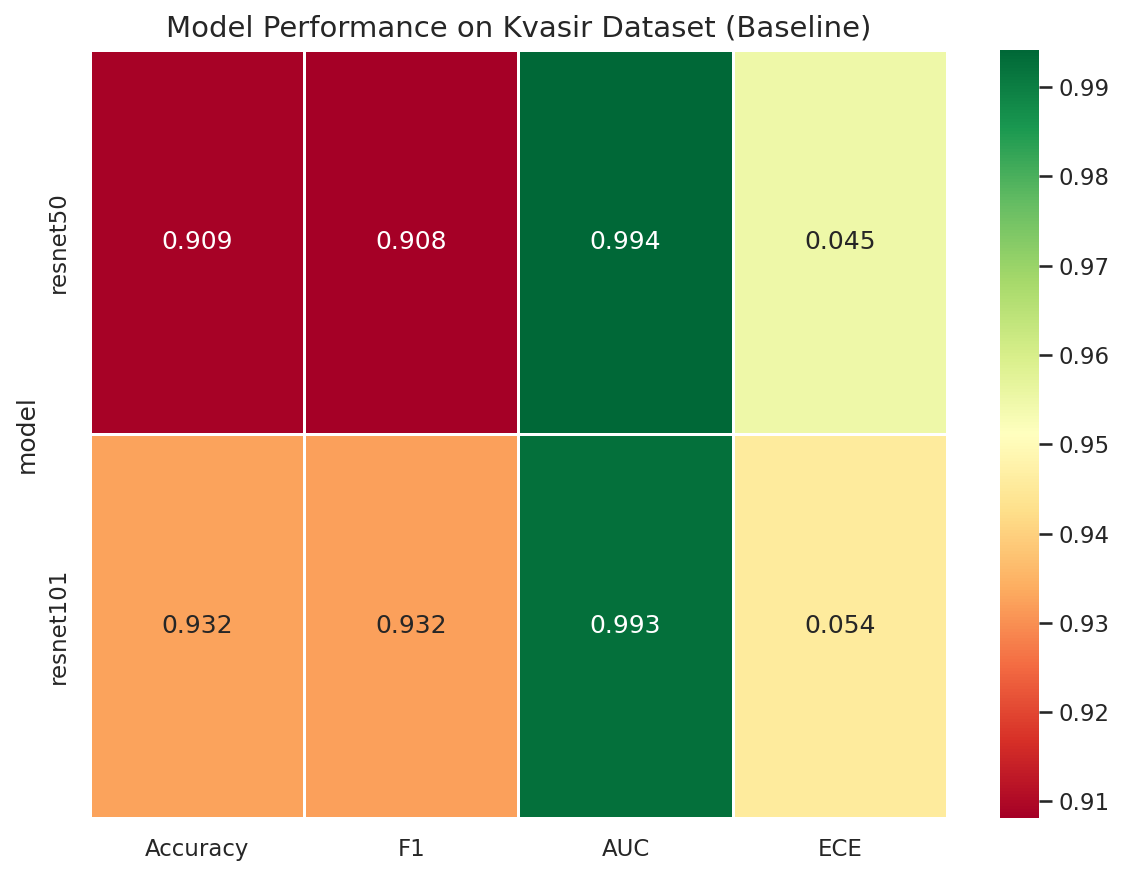

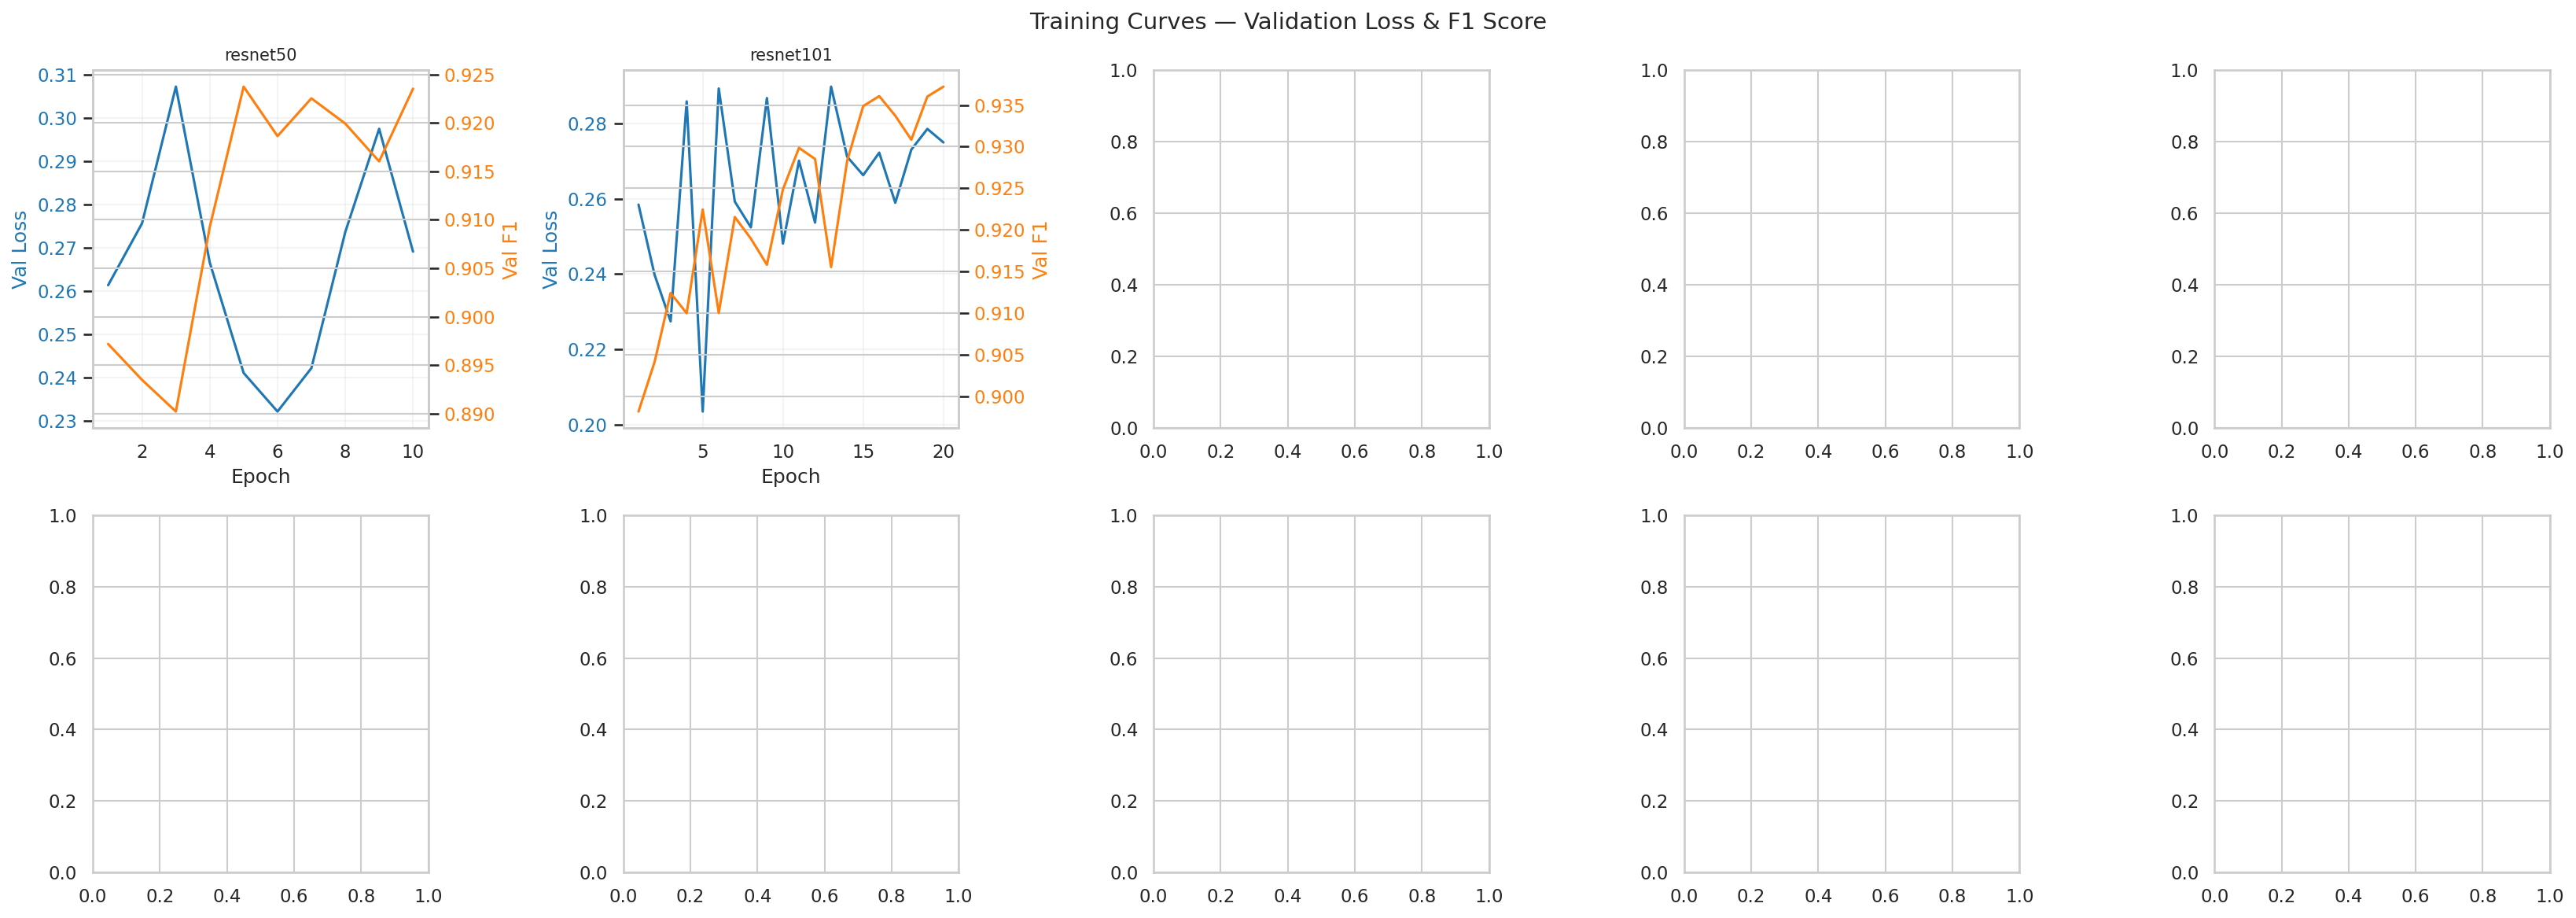

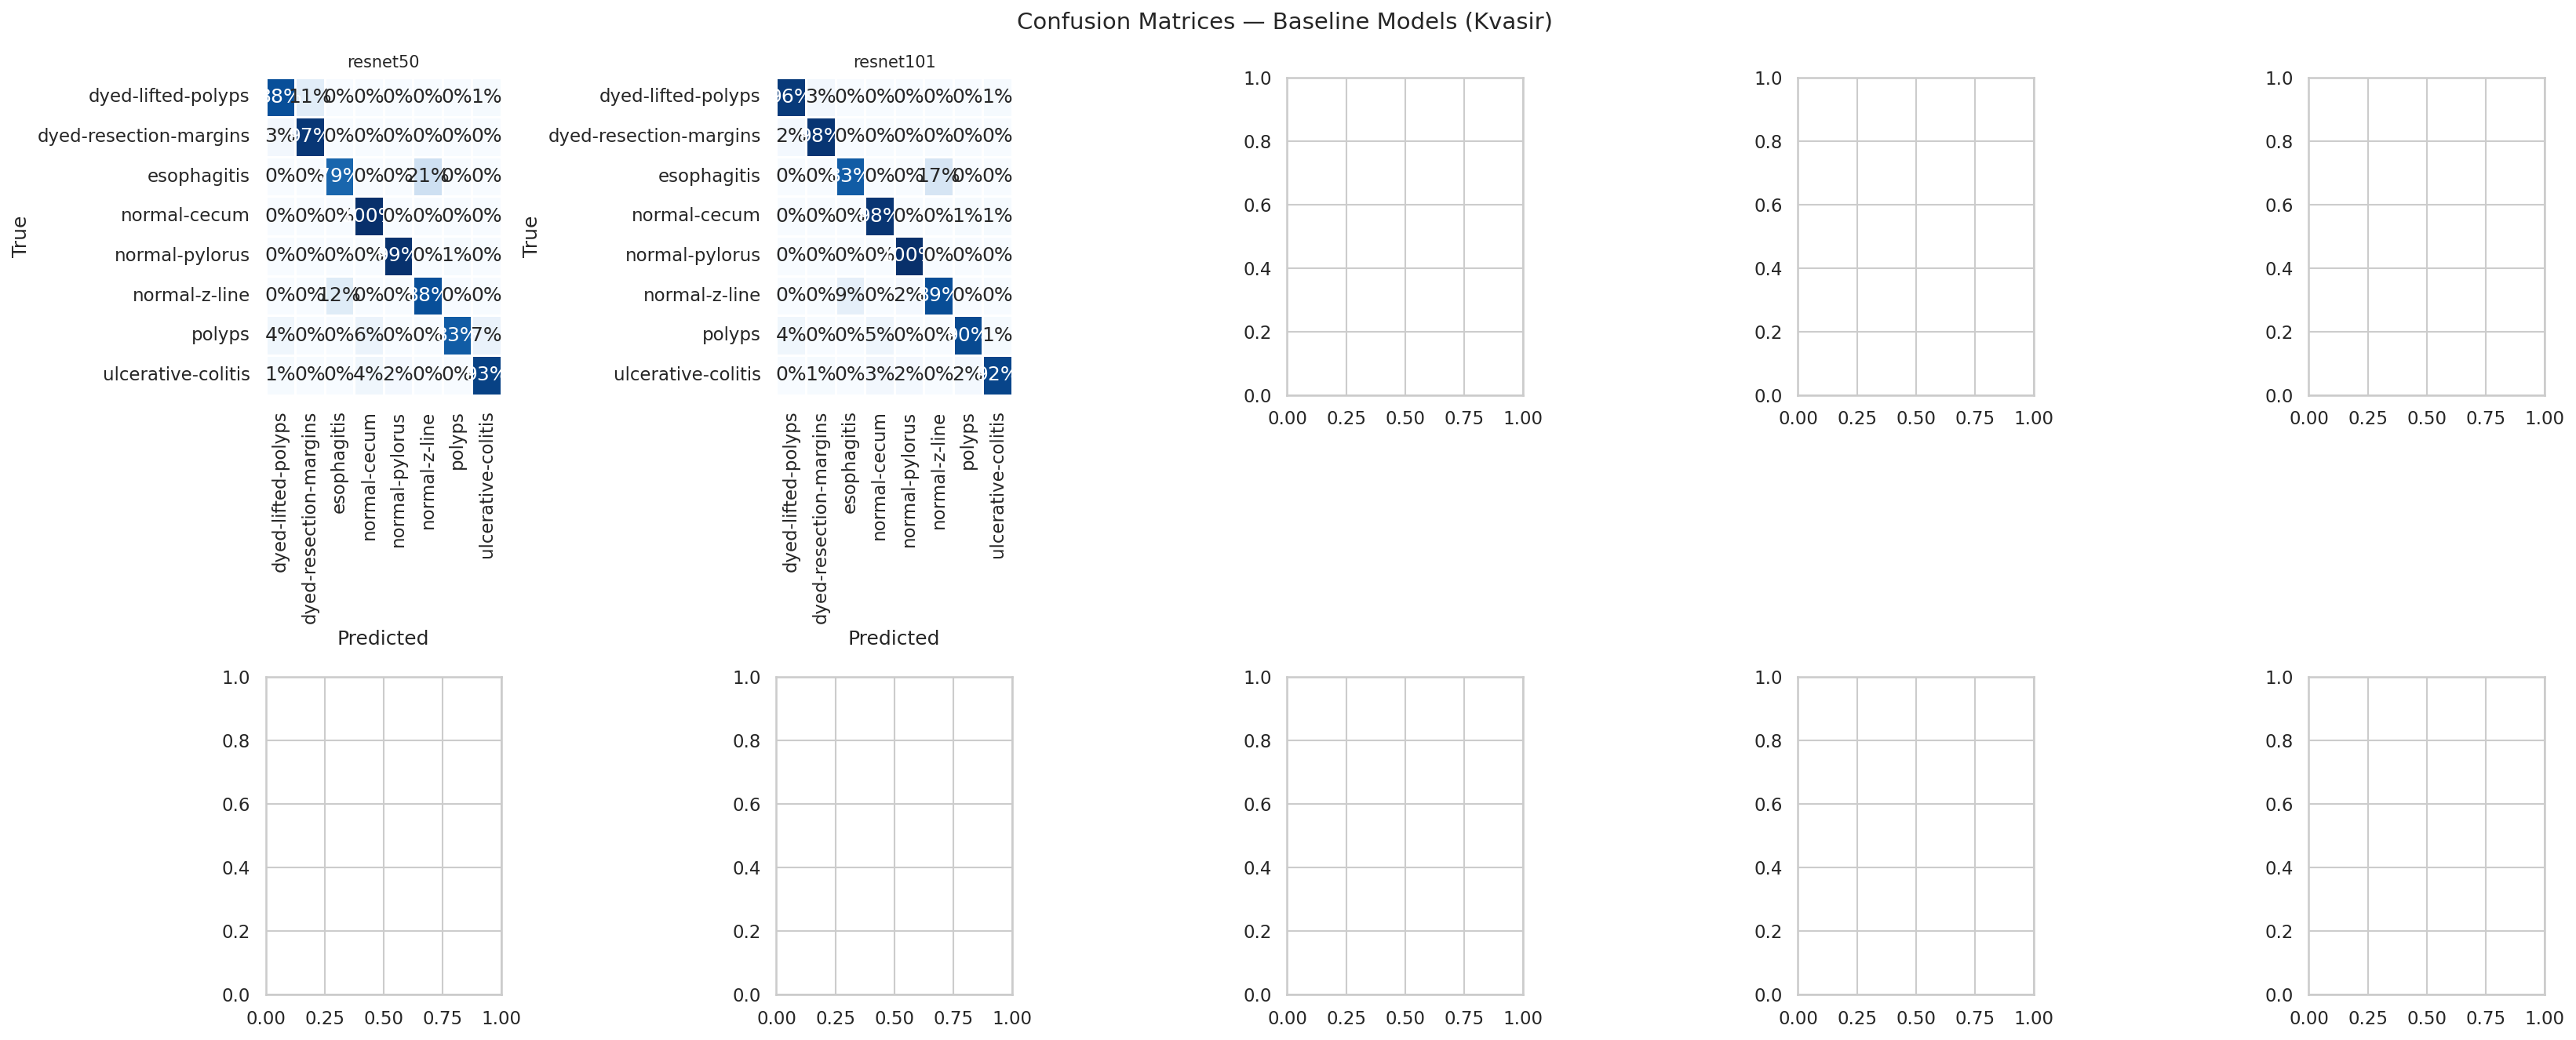

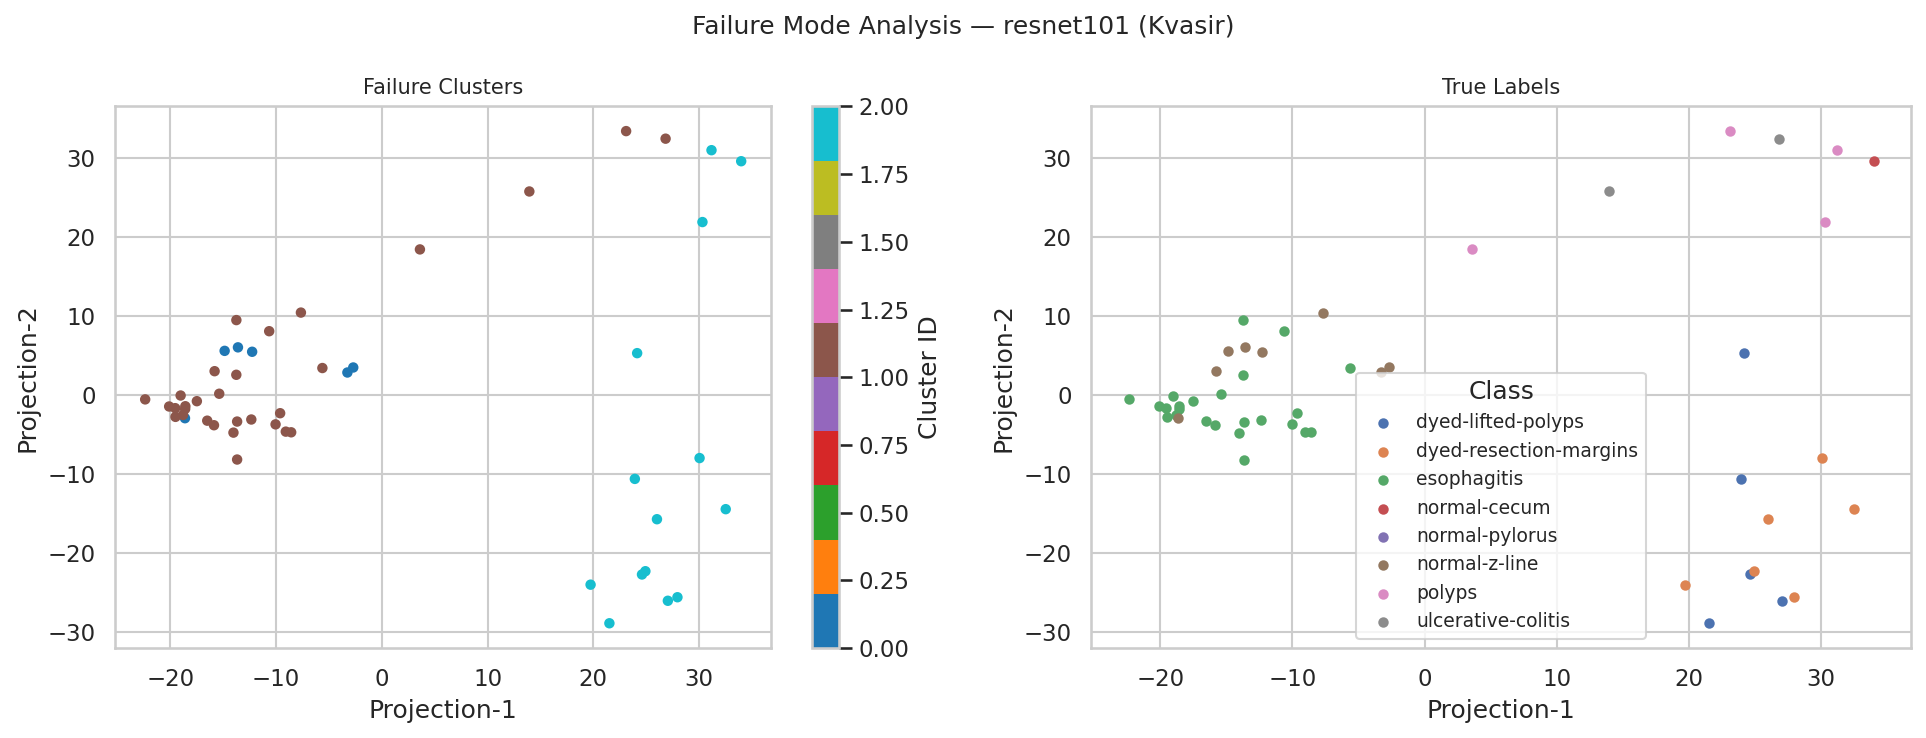

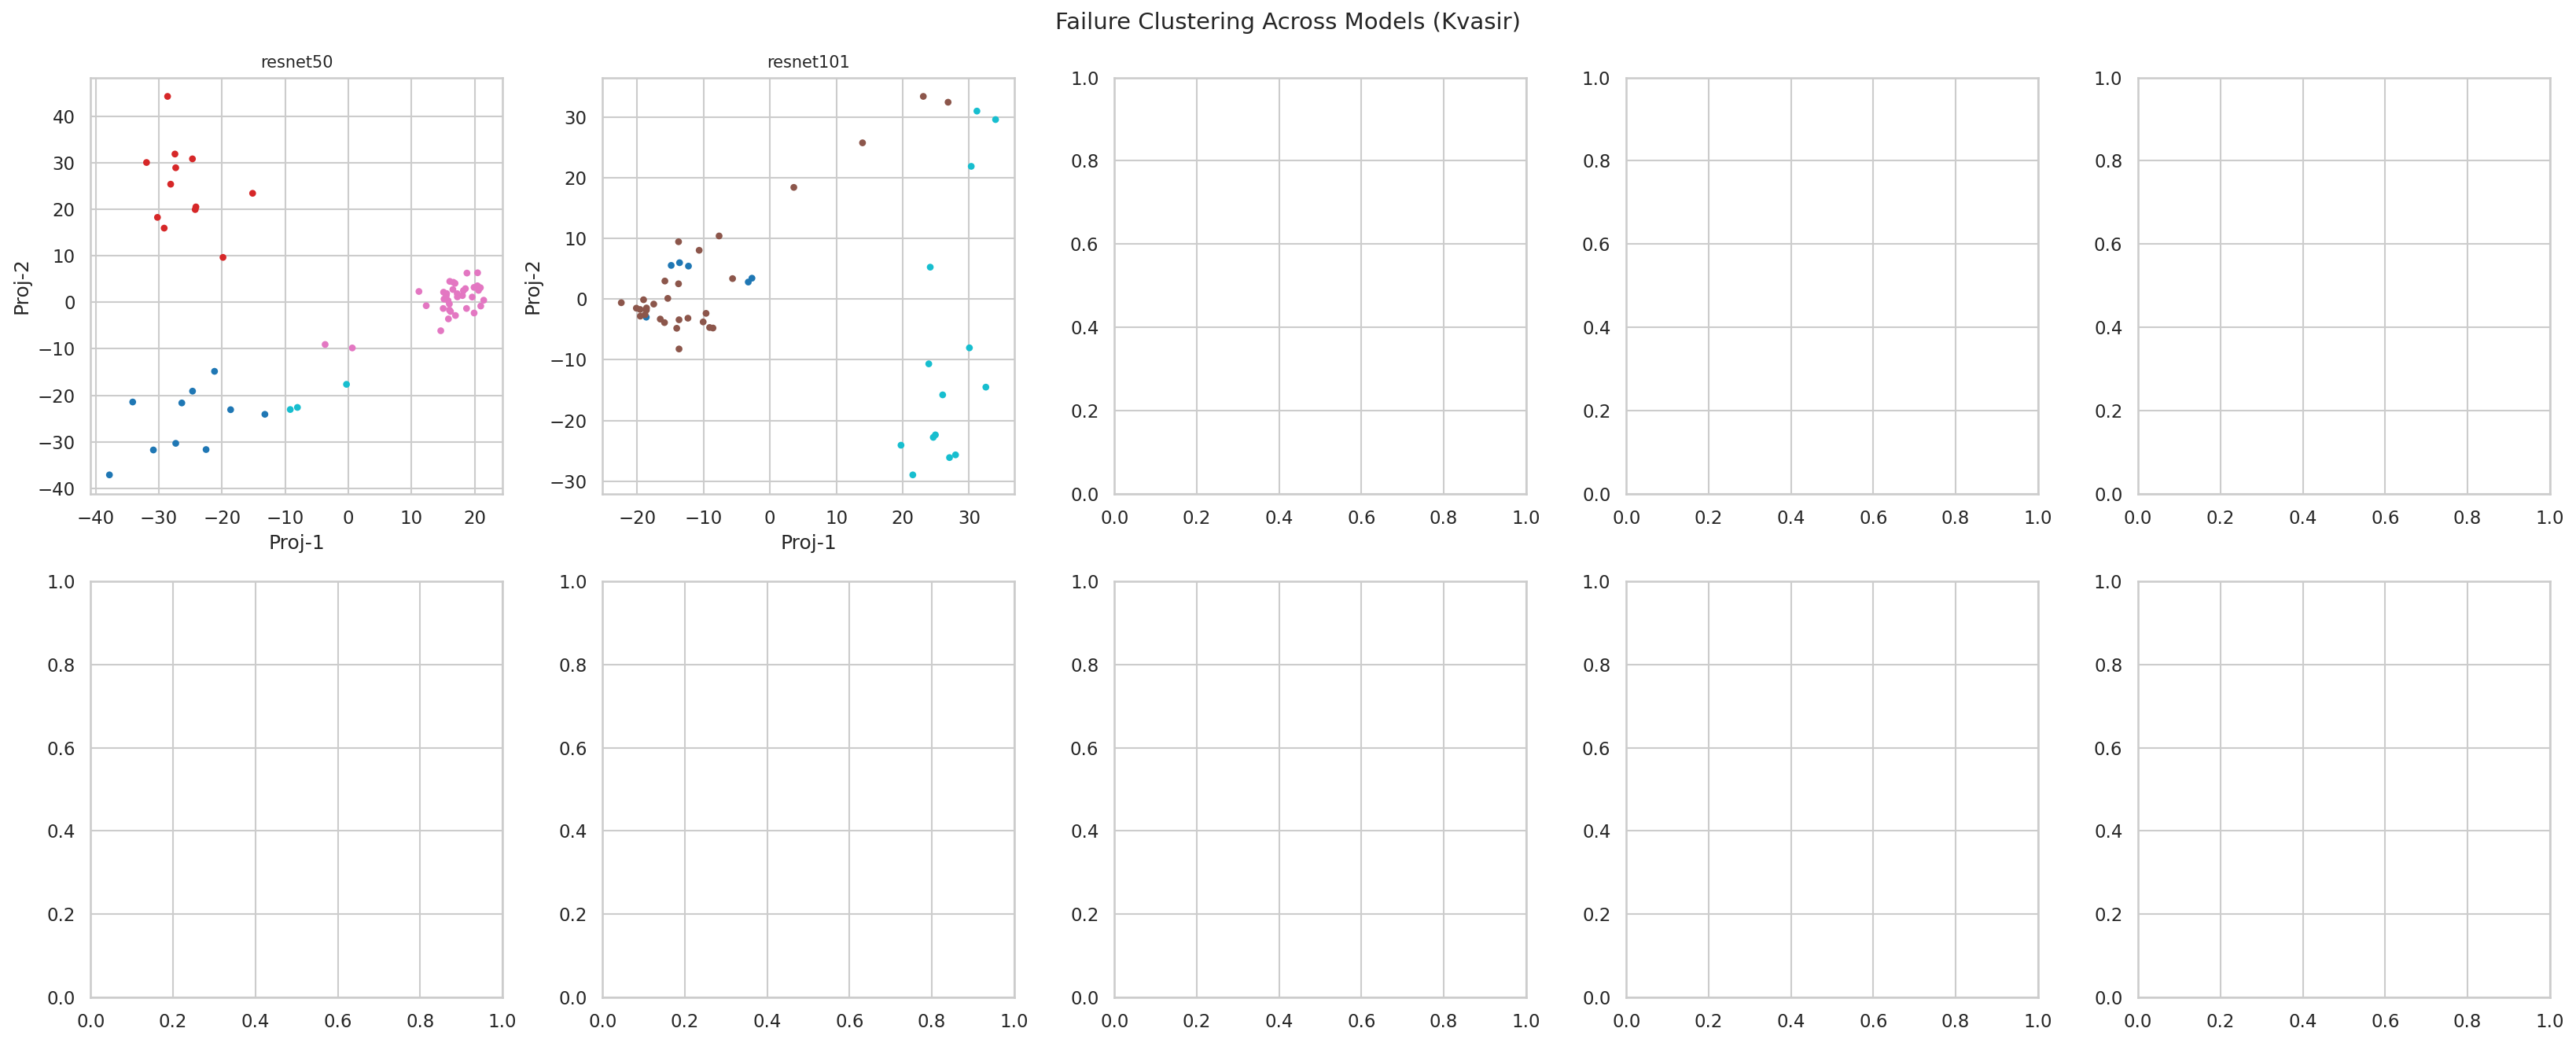

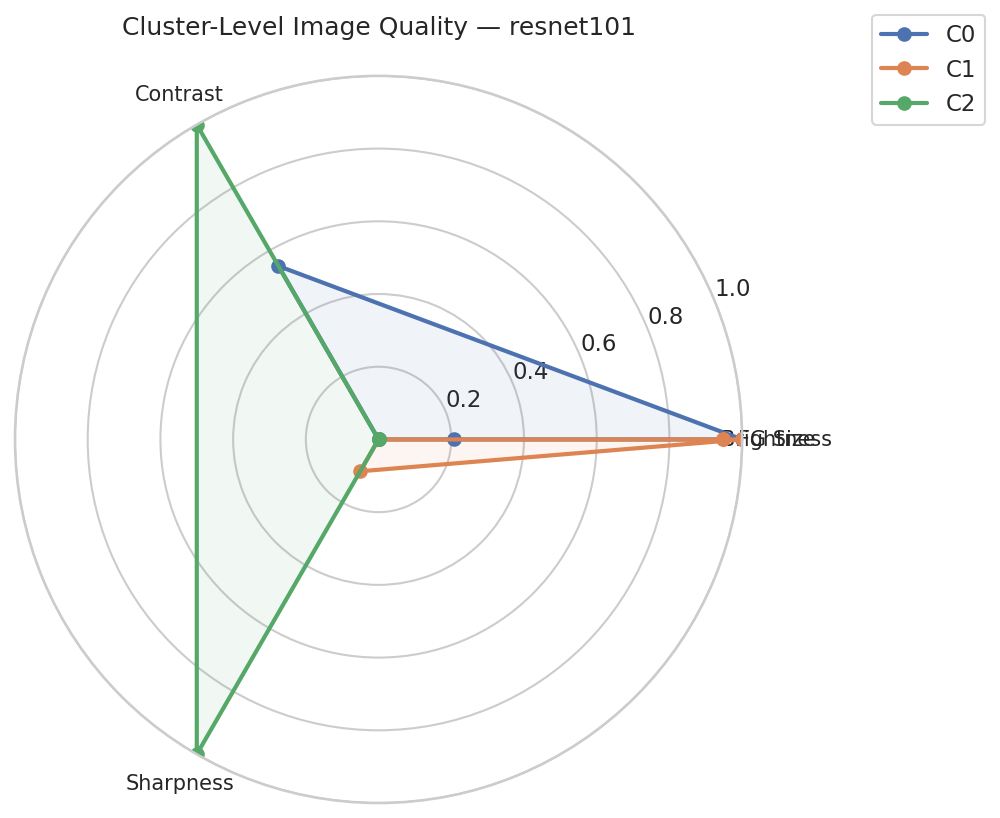

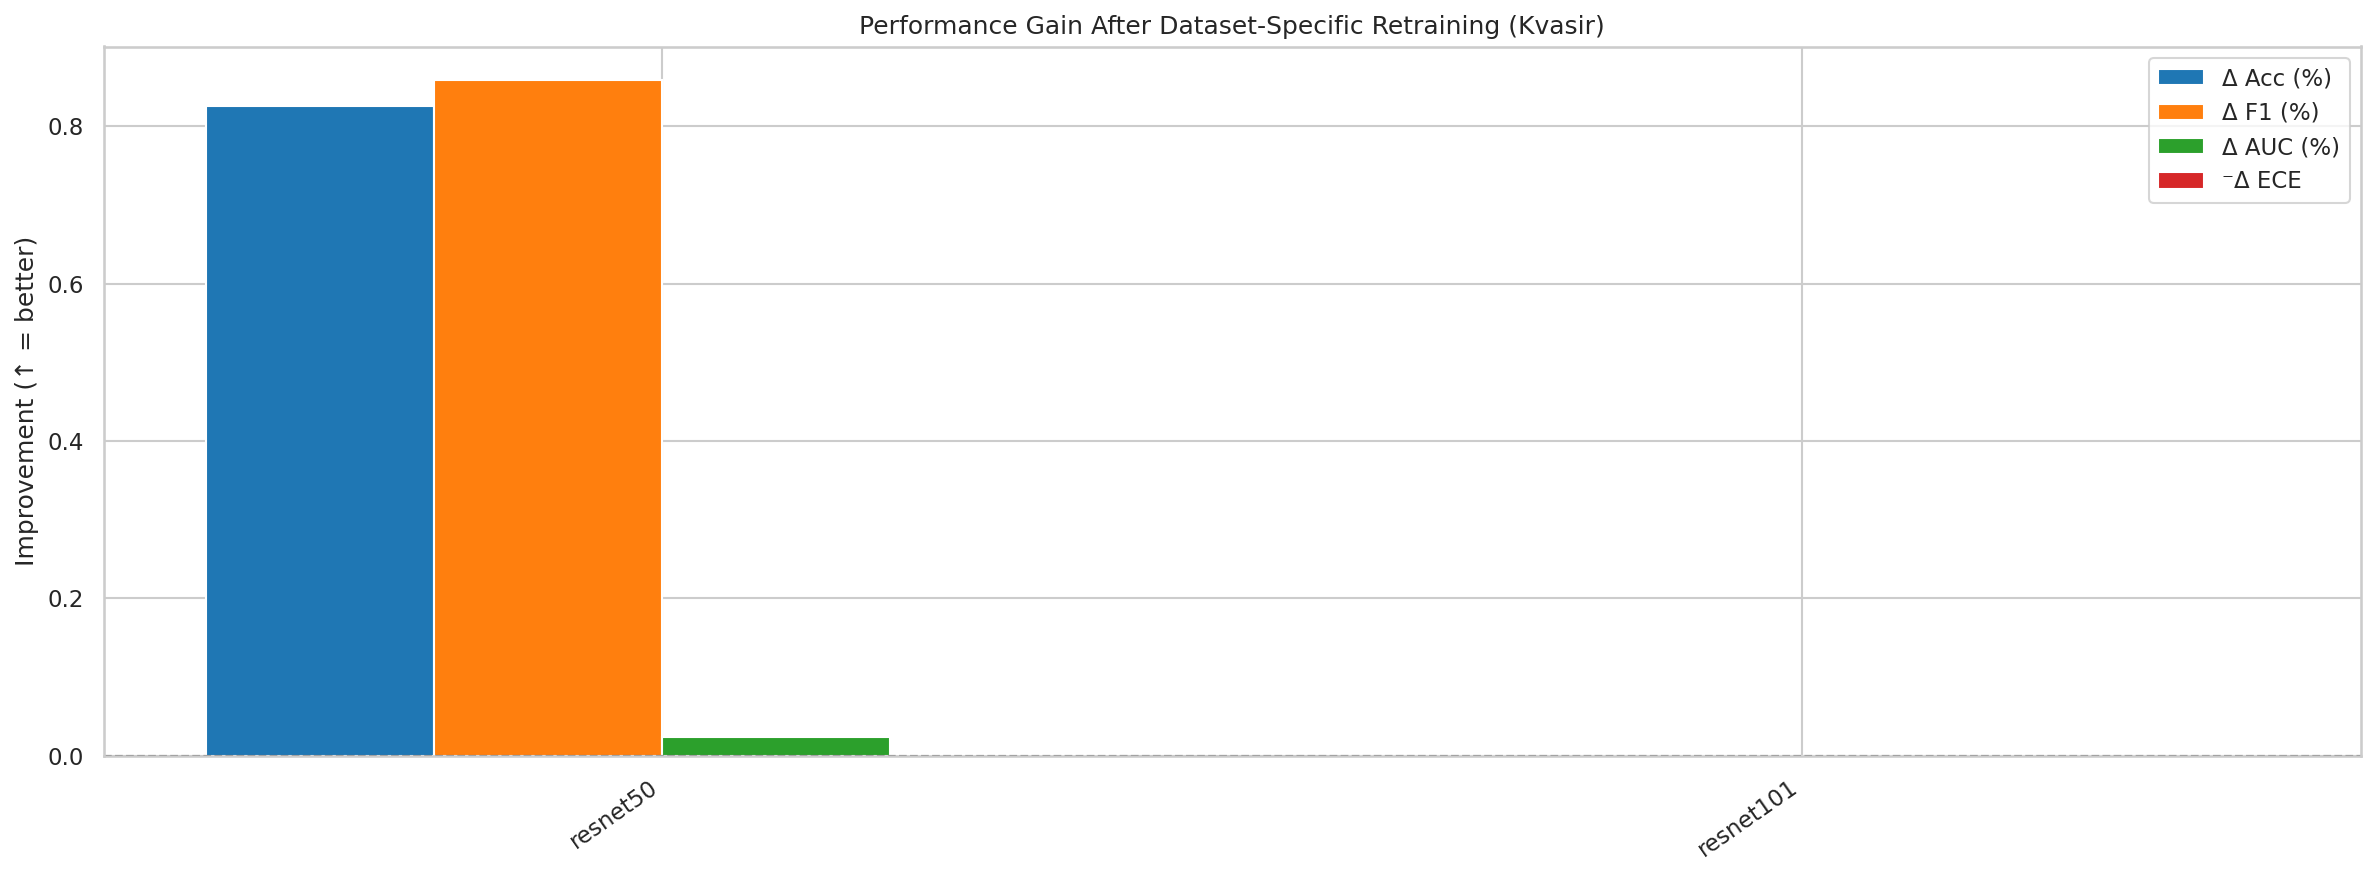

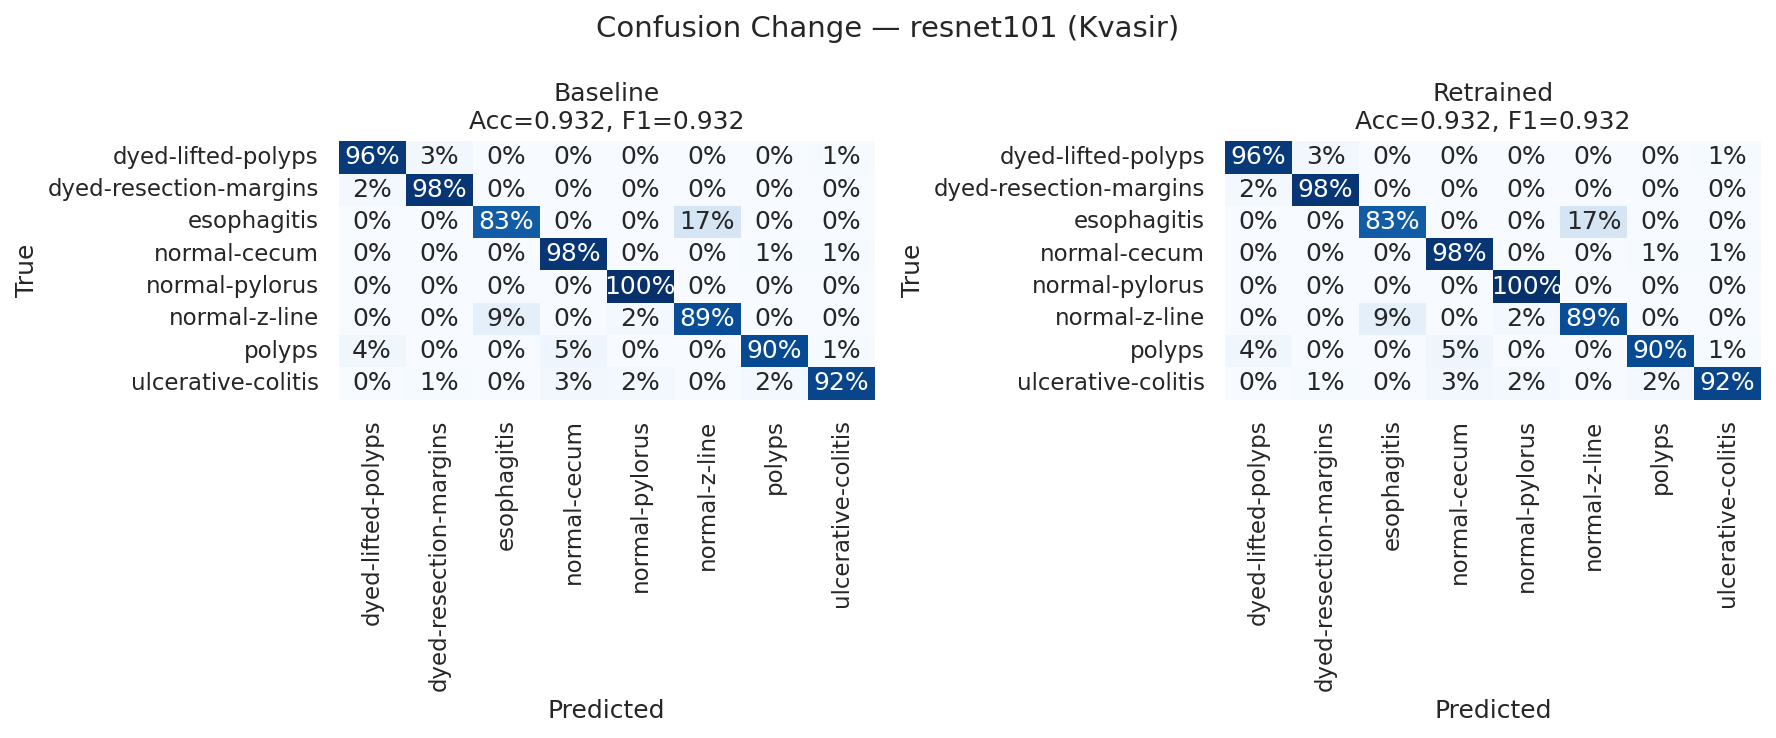

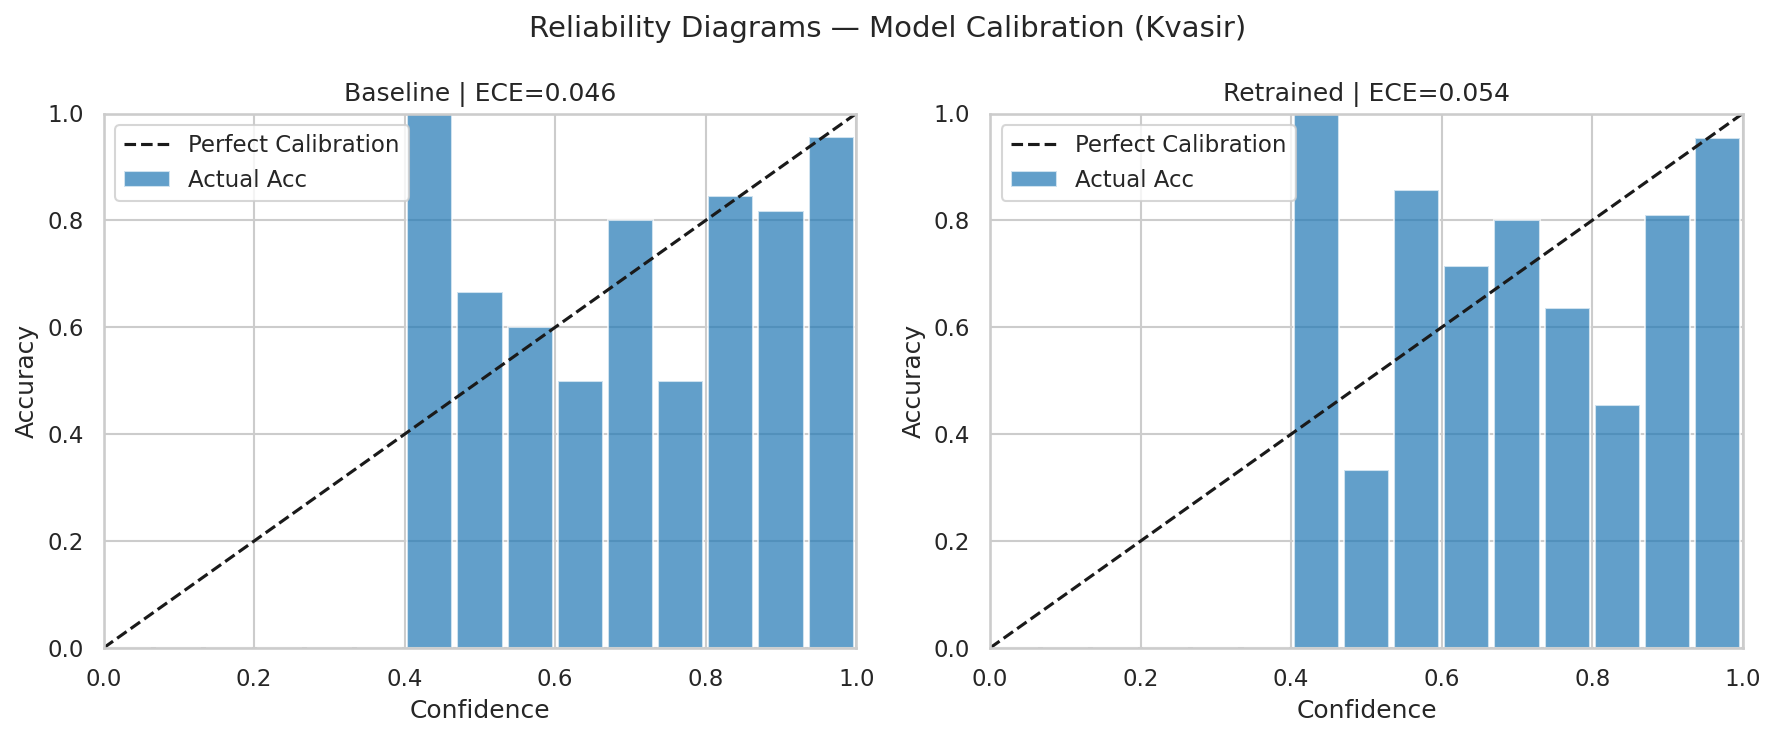

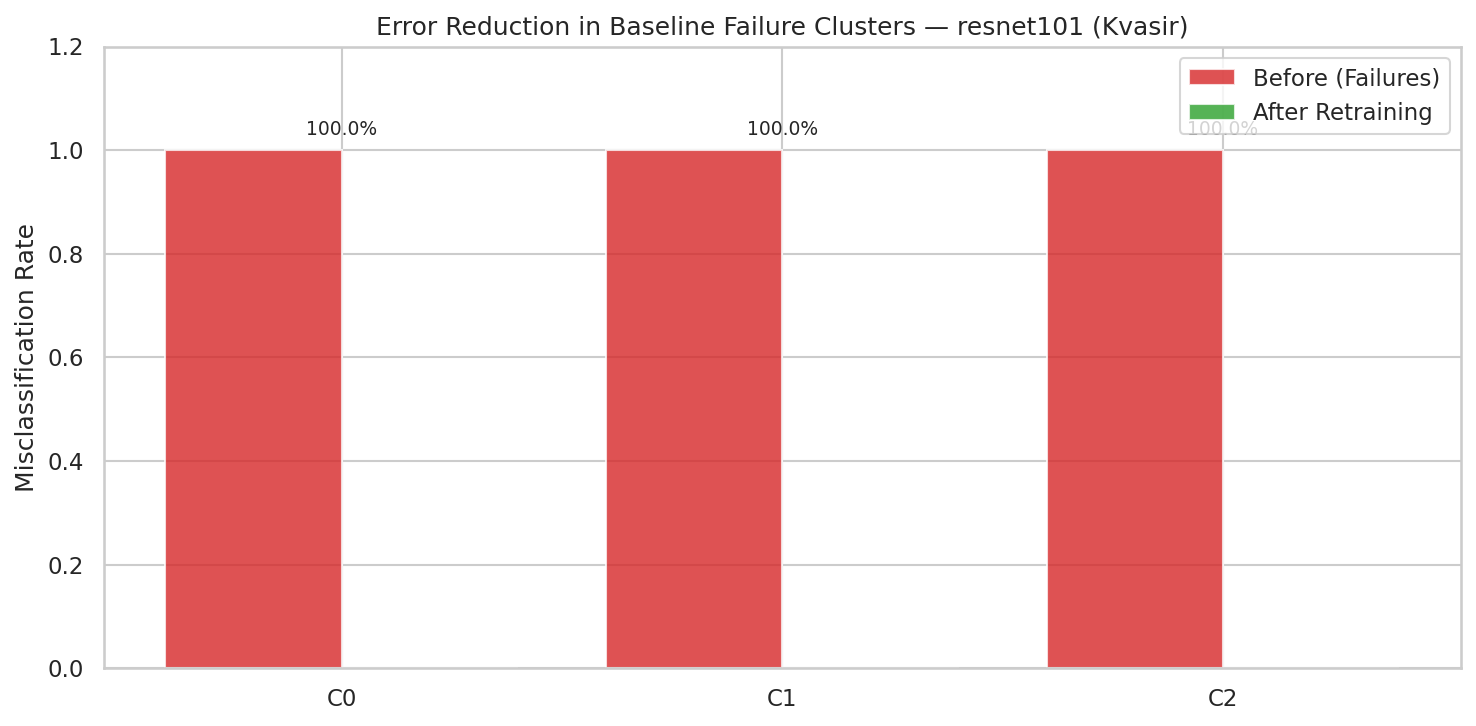


✅ Section 11 complete — All visualizations generated successfully
   Output saved to: /kaggle/working/figures


In [16]:
# ───────────────────────────────────────────────────────────────────────
# VISUALIZATION PIPELINE FOR KVASIR DATASET
# ───────────────────────────────────────────────────────────────────────
# This script generates 10 key figures analyzing model performance,
# failure modes, and retraining improvements on the Kvasir dataset.
# It assumes all required data is precomputed and stored in CONFIG and
# global DataFrames like baseline_df, improvement_df, all_clustered, etc.
# ───────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure output directory exists
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

# Helper: reliability_bins for ECE plots
def reliability_bins(probs, labels, n_bins=15):
    """
    Compute accuracy and confidence per bin for reliability diagrams.
    Returns: bin_centers, accuracies, confidences, counts
    """
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


# Compute ECE (if not already defined)
def compute_ece(probs, labels, n_bins=15):
    centers, bacc, bconf, counts = reliability_bins(probs, labels, n_bins)
    bin_weights = counts / counts.sum()
    return np.sum(bin_weights * np.abs(bacc - bconf))

# ── Select Best Model for Focus ────────────────────────────────────────
if len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"📊 Best model selected for detailed figures: {best_model}")

# ════════════════════════════════════════════════════════════════════════
# Figure 1: Baseline Performance Heatmap
# Shows Accuracy, F1, AUC, and ECE across models. ECE inverted for "green = good".
# ════════════════════════════════════════════════════════════════════════
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].rename(columns={
    'test_accuracy': 'Accuracy',
    'test_f1': 'F1',
    'test_auc': 'AUC',
    'test_ece': 'ECE'
})

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']  # Invert so lower ECE → higher value → better

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df,
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True,
    linewidths=0.5
)
plt.title("Model Performance on Kvasir Dataset (Baseline)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 2: Training Curves (Val Loss & Val F1)
# Dual Y-axis: blue = Val Loss, orange = Val F1
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})
    if not hist or len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)
    ax.plot(epochs, hist['val_loss'], color='tab:blue', label='Val Loss')
    ax.set_ylabel('Val Loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)
    ax.grid(True, alpha=0.2)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.suptitle("Training Curves — Validation Loss & F1 Score", fontsize=14, y=0.97)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig2_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 3: Normalized Confusion Matrices (Baseline)
# One per model, row-normalized (per-class recall shown)
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue
    cm = baseline_confusions[model_name]
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False,
        linewidths=0.5
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle("Confusion Matrices — Baseline Models (Kvasir)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 4: UMAP Projection — Clusters vs True Labels (Best Model)
# Left: Cluster assignments, Right: True classes
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered:
    best_clustered = all_clustered[best_model]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

    # Left: Failure Clusters
    sc = axes[0].scatter(
        best_clustered['umap_x'], best_clustered['umap_y'],
        c=best_clustered['cluster'], cmap='tab10', s=16
    )
    axes[0].set_title('Failure Clusters', fontsize=10)
    axes[0].set_xlabel('Projection-1')
    axes[0].set_ylabel('Projection-2')
    plt.colorbar(sc, ax=axes[0], label='Cluster ID')

    # Right: True Labels
    for label_id, name in enumerate(CONFIG['class_names']):
        sub = best_clustered[best_clustered['true_label'] == label_id]
        axes[1].scatter(sub['umap_x'], sub['umap_y'], s=16, label=name)
    axes[1].set_title('True Labels', fontsize=10)
    axes[1].set_xlabel('Projection-1')
    axes[1].set_ylabel('Projection-2')
    axes[1].legend(title='Class', fontsize=9)

    plt.suptitle(f"Failure Mode Analysis — {best_model} (Kvasir)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig4_projection_best_model.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 4: no clustered data for best model")


# ════════════════════════════════════════════════════════════════════════
# Figure 5: UMAP Projection for All Models (Cluster View)
# Shows 2D cluster distribution per model
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue
    cdf = all_clustered[model_name]
    sc = ax.scatter(cdf['umap_x'], cdf['umap_y'], c=cdf['cluster'], cmap='tab10', s=10)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Proj-1')
    ax.set_ylabel('Proj-2')

plt.suptitle("Failure Clustering Across Models (Kvasir)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/fig5_projection_all_models.png", dpi=300, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════════════════
# Figure 6: Radar Chart of Cluster-Level Image Quality (Best Model)
# Compares Brightness, Contrast, Sharpness, Foreground Size across clusters
# ════════════════════════════════════════════════════════════════════════
if best_model in all_profiles and not all_profiles[best_model].empty:
    profile_df = all_profiles[best_model]
    feats = ['brightness_mean', 'contrast_mean', 'sharpness_mean', 'foreground_size_mean']
    radar = profile_df[['cluster'] + feats].copy()

    # Normalize
    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx <= mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats)).tolist()
    angles += angles[:1]  # Close loop

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats] + [row[feats[0]]]
        ax.plot(angles, values, marker='o', linewidth=2, label=f"C{int(row['cluster'])}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['Brightness', 'Contrast', 'Sharpness', 'FG Size'], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster-Level Image Quality — {best_model}", fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig6_cluster_radar.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 6: no cluster profile data available")


# ════════════════════════════════════════════════════════════════════════
# Figure 7: Performance Improvement After Retraining
# Δ Acc, F1, AUC (positive = good), and -Δ ECE
# ════════════════════════════════════════════════════════════════════════
if len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2
    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc (%)'),
        ('delta_f1_pct', 'Δ F1 (%)'),
        ('delta_auc_pct', 'Δ AUC (%)'),
        ('delta_ece', '⁻Δ ECE')  # Negative delta → smaller ECE = improvement
    ]
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, (col, label) in enumerate(metrics):
        vals = improvement_df[col].values
        if col == 'delta_ece':
            vals = -vals  # Negative means improvement
        ax.bar(x + (i - 1.5) * width, vals, width, label=label, color=colors[i])

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Improvement (↑ = better)')
    ax.set_title("Performance Gain After Dataset-Specific Retraining (Kvasir)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig7_improvement_bars.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 7: no retraining results found")


# ════════════════════════════════════════════════════════════════════════
# Figure 8: Confusion Matrix Before vs After Retraining
# Side-by-side comparison for the best model
# ════════════════════════════════════════════════════════════════════════
if best_model in retrained_confusions and len(improvement_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0]

    items = [
        (
            axes[0],
            baseline_confusions[best_model],
            f"Baseline\nAcc={base_row['test_accuracy']:.3f}, F1={base_row['test_f1']:.3f}"
        ),
        (
            axes[1],
            retrained_confusions[best_model],
            f"Retrained\nAcc={ret_row['retrained_acc']:.3f}, F1={ret_row['retrained_f1']:.3f}"
        )
    ]

    for ax, cm, title in items:
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            cbar=False,
            vmin=0, vmax=1
        )
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plt.suptitle(f"Confusion Change — {best_model} (Kvasir)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 8: missing retraining confusion matrices")


# ════════════════════════════════════════════════════════════════════════
# Figure 9: Reliability Diagrams — Baseline vs Retrained
# Bar chart: accuracy per confidence bin; diagonal line = ideal
# ════════════════════════════════════════════════════════════════════════
if best_model in retrained_predictions:
    base_pred = all_predictions[best_model]
    base_probs = np.stack(base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=',')))
    base_labels = base_pred['true_label'].values

    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
    items = [
        (axes[0], base_probs, base_labels, f"Baseline | ECE={compute_ece(base_probs, base_labels):.3f}"),
        (axes[1], ret_probs, ret_labels, f"Retrained | ECE={compute_ece(ret_probs, ret_labels):.3f}")
    ]

    for ax, probs, labels, title in items:
        centers, bacc, _, _ = reliability_bins(probs, labels, CONFIG['ece_bins'])
        ax.bar(centers, bacc, width=0.9 / CONFIG['ece_bins'], alpha=0.7, color='tab:blue', label='Actual Acc')
        ax.plot([0, 1], [0, 1], '--', color='k', label='Perfect Calibration')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_title(title)
        ax.legend()

    plt.suptitle("Reliability Diagrams — Model Calibration (Kvasir)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig9_ece_reliability.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 9: missing retrained predictions")


# ════════════════════════════════════════════════════════════════════════
# Figure 10: Residual Error Reduction by Cluster
# Compares baseline failure rate vs post-retraining residual error
# ════════════════════════════════════════════════════════════════════════
if best_model in all_clustered and best_model in retrained_predictions:
    clustered = all_clustered[best_model]
    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    clusters = sorted(clustered['cluster'].unique())
    before_rates = [1.0] * len(clusters)  # All baseline failures = baseline error clusters
    after_rates = []

    for c in clusters:
        sub = ret_clustered[ret_clustered['cluster'] == c]
        err_rate = float((sub['true_label'] != sub['pred_label']).mean()) if len(sub) > 0 else 0
        after_rates.append(err_rate)

    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    ax.bar(x - 0.2, before_rates, 0.4, color='tab:red', label='Before (Failures)', alpha=0.8)
    ax.bar(x + 0.2, after_rates, 0.4, color='tab:green', label='After Retraining', alpha=0.8)

    # Add improvement percentage on top
    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(i, max(b, a) + 0.03, f"{(b - a)*100:.1f}%", ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Misclassification Rate')
    ax.set_ylim(0, 1.2)
    ax.set_title(f"Error Reduction in Baseline Failure Clusters — {best_model} (Kvasir)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Skipping Figure 10: missing clustering or prediction data")

# ✅ Final Status
print("\n✅ Section 11 complete — All visualizations generated successfully")
print(f"   Output saved to: {CONFIG['figures_dir']}")

In [17]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 12: Final Summary Report — Breast Ultrasound (BUSI)
# ─────────────────────────────────────────────────────────────────────
# This script generates a human-readable Markdown summary assessing:
# - Model performance (baseline vs retrained)
# - Most improved model after retraining
# - Dominant misclassification patterns
# - Deployment recommendations
# Output saved as `FINAL_SUMMARY_BUSI.md`
# ─────────────────────────────────────────────────────────────────────

from collections import Counter
from pathlib import Path


def pretty_model_name(name: str) -> str:
    """
    Convert internal model identifier to human-readable display name.
    Unified across datasets.
    """
    return {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }.get(name, name)


print("📘 Generating final summary for Breast Ultrasound (BUSI) dataset...")

# Ensure results directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────
# Build Markdown Summary
# ─────────────────────────────────────────────────────────────────────
summary_lines = []

# ── 1. Retraining Results Table (if available) ─────────────────────
if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base→ret) | F1 (base→ret) | "
        "AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}→{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}→{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}→{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}→{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append(
        "📌 **Retraining results are unavailable** — `improvement_df` is empty or not computed."
    )
    summary_lines.append(
        "   Ensure Section 10 (Retraining) completed successfully."
    )

# ── 2. Best Baseline Model ─────────────────────────────────────────
best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values('test_f1', ascending=False).iloc[0]

final_best_baseline = (
    f"- 🏆 **Best baseline model**: {pretty_model_name(best_baseline['model'])} "
    f"(F1 = {best_baseline['test_f1']:.3f}, "
    f"Acc = {best_baseline['test_accuracy']:.3f}, "
    f"AUC = {best_baseline['test_auc']:.3f}, "
    f"ECE = {best_baseline['test_ece']:.3f})"
    if best_baseline is not None else
    "- 🏆 **Best baseline model**: unavailable"
)

# ── 3. Most Improved Model After Retraining ───────────────────────
most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values('delta_f1_pct', ascending=False).iloc[0]

final_most_improved = (
    f"- 📈 **Most improved model**: {pretty_model_name(most_improved['model'])} "
    f"(ΔF1 = {most_improved['delta_f1_pct']:+.1f}%, "
    f"final F1 = {most_improved['retrained_f1']:.3f})"
    if most_improved is not None else
    "- 📈 **Most improved model**: unavailable"
)

# ── 4. Dominant Misclassification Pattern Across Models ───────────
all_failure_pairs = []
for failure_df in all_failures.values():
    if len(failure_df) > 0:
        all_failure_pairs.extend(zip(failure_df['true_label'], failure_df['pred_label']))

if all_failure_pairs:
    most_common_pair, count = Counter(all_failure_pairs).most_common(1)[0]
    true_class, pred_class = most_common_pair
    true_name = CONFIG['class_names'][true_class]
    pred_name = CONFIG['class_names'][pred_class]
    dominant_text = f"**{true_name} → {pred_name}** (n={count})"
else:
    dominant_text = "No consistent misclassification pattern detected"

# ── 5. Clinical/Deployment Recommendation (BUSI-specific) ──────────
clinical_recommendation = (
    "✅ Use the retrained best-performing model only as an assistant "
    "for breast ultrasound interpretation — **never for autonomous diagnosis**. "
    "Deployment must include:\n"
    "   • Calibration monitoring (especially ECE)\n"
    "   • Regular audits of failure clusters (e.g., image quality, probe angles)\n"
    "   • Pathologist or radiologist review for all malignant predictions\n"
    "   • Prospective validation on local institutional data before clinical use.\n"
    "\n"
    "❗ Pay special attention to differentiating **benign masses** from **malignant** ones — "
    "the most common confusion in this study. Monitor scan quality (e.g., brightness, "
    "focus depth, speckle noise), which may confound model predictions."
)

# ── 6. Final Assembly of Summary Text ────────────────────────────
final_text = "\n".join(summary_lines)
final_text += "\n\n" + final_best_baseline
final_text += "\n" + final_most_improved
final_text += f"\n- 📁 **Dataset**: Breast Ultrasound Image (BUSI) – 3-class (Benign, Malignant, Normal)"
final_text += f"\n- 🎯 **Most frequent misclassification**: {dominant_text}"
final_text += f"\n\n🔹 **Clinical Deployment Guidance**:\n{clinical_recommendation}"
final_text += f"\n\n\n📝 *This summary synthesizes all models, retraining results, and failure analysis on BUSI. " \
              f"For figures and raw data, see the 'figures/' and 'results/' directories. Always validate " \
              f"new models on institutional data before deployment.*"

# ── 7. Save to Disk ───────────────────────────────────────────────
summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_BUSI.md'
summary_path.write_text(final_text, encoding='utf-8')

# ── 8. Console Output ─────────────────────────────────────────────
print("\n" + "━" * 80)
print("📘 FINAL SUMMARY — Breast Ultrasound (BUSI) Dataset")
print("━" * 80)
print(final_text.strip())
print("━" * 80)
print(f"✅ Final summary saved to:\n   {summary_path.resolve()}")
print("✓ Section 12 complete — Summary generation finished")


# Optional: Also write a plain-text log version
(Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_BUSI.txt').write_text(final_text, encoding='utf-8')

📘 Generating final summary for Breast Ultrasound (BUSI) dataset...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📘 FINAL SUMMARY — Breast Ultrasound (BUSI) Dataset
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
| Model | Family | Acc (base→ret) | F1 (base→ret) | AUC (base→ret) | ECE (base→ret) | Δ Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ResNet-50 | CNN | 0.909→0.916 | 0.908→0.916 | 0.994→0.994 | 0.045→0.044 | +0.8% | Selective |
| ResNet-101 | CNN | 0.932→0.932 | 0.932→0.932 | 0.993→0.993 | 0.054→0.054 | +0.0% | Selective |

- 🏆 **Best baseline model**: ResNet-101 (F1 = 0.932, Acc = 0.932, AUC = 0.993, ECE = 0.054)
- 📈 **Most improved model**: ResNet-50 (ΔF1 = +0.9%, final F1 = 0.916)
- 📁 **Dataset**: Breast Ultrasound Image (BUSI) – 3-class (Benign, Malignant, Normal)
- 🎯 **Most frequent misclassification**: **esophagitis → normal-z-line** (n=41)

🔹 **Clinical Deployment Guidance**:
✅ Use the ret

1605

In [18]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 13: Save Cross-Notebook Compatible Results — Kvasir Dataset
# ─────────────────────────────────────────────────────────────────────
# This script saves key analysis results in a standardized format
# designed for cross-dataset comparison (e.g., Kvasir vs BUSI).
# Files are saved to CONFIG['results_dir'] with dataset-specific tags.
# ─────────────────────────────────────────────────────────────────────

from pathlib import Path
import pandas as pd

DATASET_NAME = 'kvasir'
DATASET_DISPLAY = 'Kvasir v2 (GI-Endoscopy)'

print(f"🌐 Saving cross-notebook results for {DATASET_DISPLAY}...")

# Ensure output directory exists
Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ── 1. Improvement Results (Retrained vs Baseline) ──────────────────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME  # Tag with dataset name
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved improvement results: {len(improvement_df_export)} models → {out_path}")
else:
    print("  ⚠️  improvement_df not found or empty — skipping improvement export")

# ── 2. Untargeted Control Results (Compute-Matched Baseline) ─────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  ✅ Saved untargeted control: {len(untargeted_df_export)} models → {out_path}")
else:
    print("  ⚠️  untargeted_df not found or empty — skipping untargeted control export")

# ── 3. Cluster Summary (Failure Clustering Metadata) ────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        # Get number of misclassified samples (failures) for this model
        n_failures = len(all_failures[model_name]) if (model_name in all_failures) else 0

        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  ✅ Saved cluster summaries: {len(cluster_summary_df)} rows → {out_path}")
else:
    print("  ⚠️  No clustering summaries available — skipping cluster export")

# ── 4. Temperature Scaling Results (Calibration) ─────────────────────
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  ✅ Saved temperature scaling: {len(temp_export)} rows → {out_path}")
    else:
        missing_cols = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  ⚠️  Missing temp scaling columns: {missing_cols} — skipping export")
else:
    print("  ⚠️  baseline_df not available — skipping temperature scaling export")

# ── Final Summary Message ──────────────────────────────────────────
print(f"\n✅ All cross-notebook result files saved for dataset='{DATASET_NAME}'")
print(f"   Files written to: {CONFIG['results_dir']}")
print(f"   Dataset: {DATASET_DISPLAY} (8-class GI tract pathology)")
print(f"   Next step: Run `Section 13: Cross-Dataset Comparison` to merge with other datasets.")

🌐 Saving cross-notebook results for Kvasir v2 (GI-Endoscopy)...
  ✅ Saved improvement results: 2 models → /kaggle/working/results/improvement_kvasir.csv
  ✅ Saved untargeted control: 2 models → /kaggle/working/results/untargeted_control_kvasir.csv
  ✅ Saved cluster summaries: 2 rows → /kaggle/working/results/cluster_summary_kvasir.csv
  ⚠️  Missing temp scaling columns: ['temperature', 'test_ece_temp_scaled'] — skipping export

✅ All cross-notebook result files saved for dataset='kvasir'
   Files written to: /kaggle/working/results
   Dataset: Kvasir v2 (GI-Endoscopy) (8-class GI tract pathology)
   Next step: Run `Section 13: Cross-Dataset Comparison` to merge with other datasets.
